# 准备工作

In [65]:
import os
import pandas as pd
import numpy as np
import re

# 探索性数据分析
import matplotlib.pyplot as plt
import seaborn as sns

# 房价模型
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import statsmodels.api as sm

# 时间分类
from datetime import datetime
from scipy.stats import pearsonr

# Empirical IO
from scipy.optimize import minimize

In [3]:
new_path = r"C:\Users\ading\链家"
os.chdir(new_path)

In [5]:
df = pd.read_excel('广州链家成交数据.xlsx')

# 数据预处理

In [7]:
# 创建副本避免修改原数据
df_clean = df.copy()

# 1. 单价变成没有单位的
df_clean['unit_price'] = df_clean['unit_price'].str.replace('元/平', '').str.replace('元/平米', '').astype(float)

# 2. 删除layout变量下面是"车位"的行
df_clean = df_clean[df_clean['layout'] != '车位']

# 3. area下面去除单位"平米"
df_clean['area'] = df_clean['area'].str.replace('平米', '').astype(float)

# 4. house_info下面，|前后分开
def split_house_info(info):
    if pd.isna(info):
        return np.nan, np.nan, np.nan
    parts = str(info).split(' | ')
    if len(parts) >= 2:
        orientation = parts[0]  # 朝向
        decoration = parts[1]   # 装修
        # 如果有第三个部分
        other = parts[2] if len(parts) > 2 else ''
        return orientation, decoration, other
    else:
        return np.nan, np.nan, np.nan

# 应用分割函数
house_info_split = df_clean['house_info'].apply(split_house_info)
df_clean['orientation'] = house_info_split.apply(lambda x: x[0])
df_clean['decoration_type'] = house_info_split.apply(lambda x: x[1])
df_clean['house_other_info'] = house_info_split.apply(lambda x: x[2])

# 5. five_years, near_subway生成虚拟变量
df_clean['five_years_dummy'] = df_clean['five_years'].astype(int)
df_clean['near_subway_dummy'] = df_clean['near_subway'].astype(int)

# 6. 处理楼层信息
def extract_floor_info(floor_str):
    if pd.isna(floor_str):
        return np.nan, np.nan
    # 提取楼层信息
    match = re.search(r'(\w+)楼层', str(floor_str))
    floor_type = match.group(1) if match else np.nan
    
    # 提取总楼层
    total_match = re.search(r'共(\d+)层', str(floor_str))
    total_floors = int(total_match.group(1)) if total_match else np.nan
    
    return floor_type, total_floors

floor_info_split = df_clean['floor_info'].apply(extract_floor_info)
df_clean['floor_type'] = floor_info_split.apply(lambda x: x[0])
df_clean['total_floors'] = floor_info_split.apply(lambda x: x[1])

# 7. 处理建筑年份
df_clean['built_year'] = pd.to_numeric(df_clean['built_year'], errors='coerce')

# 计算房龄
current_year = 2025  # 根据你的数据时间调整
df_clean['house_age'] = current_year - df_clean['built_year']

In [9]:
print("预处理前的数据形状:", df.shape)
print("预处理后的数据形状:", df_clean.shape)
print("\n前几行数据:")
print(df_clean[['district', 'area', 'unit_price', 'orientation', 'decoration_type', 
                   'five_years_dummy', 'near_subway_dummy']].head())


预处理前的数据形状: (41688, 22)
预处理后的数据形状: (40686, 29)

前几行数据:
  district    area  unit_price orientation decoration_type  five_years_dummy  \
1       岑村  179.15     33325.0           南              精装                 1   
2       岑村  156.14     27924.0         南 北              毛坯                 1   
3       岑村   84.61     27633.0           南              其他                 1   
4       岑村  132.42     27791.0           南              其他                 1   
5       岑村   77.64     37996.0          西南              精装                 0   

   near_subway_dummy  
1                  0  
2                  0  
3                  0  
4                  0  
5                  0  


# 探索性数据分析

In [11]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

描述性统计:
          unit_price          area     house_age
count   40686.000000  40685.000000  32756.000000
mean    42611.862901     76.693777     23.637654
std     20527.846602     35.654322      7.305181
min       887.000000      6.110000      2.000000
25%     28353.250000     54.270000     19.000000
50%     38760.000000     73.130000     25.000000
75%     52138.250000     91.310000     28.000000
max    309128.000000    642.740000     73.000000


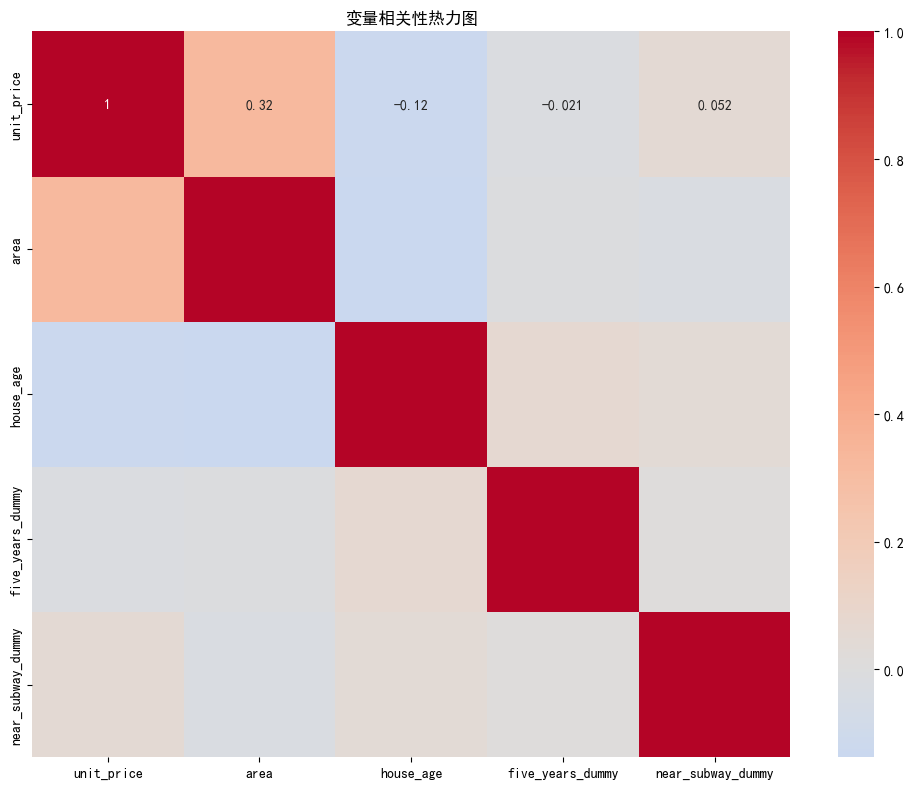

D:\Program Files\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


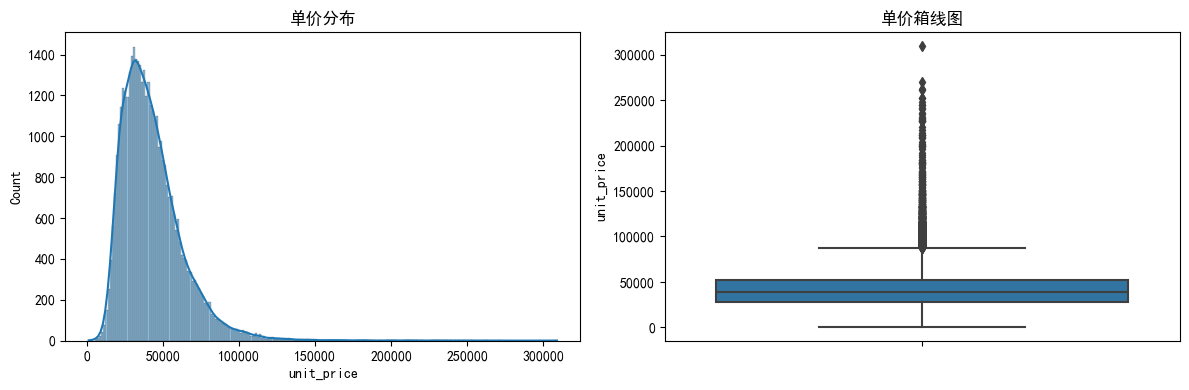

In [12]:
# 描述性统计
print("描述性统计:")
print(df_clean[['unit_price', 'area', 'house_age']].describe())

# 相关性分析
plt.figure(figsize=(10, 8))
numeric_cols = ['unit_price', 'area', 'house_age', 'five_years_dummy', 'near_subway_dummy']
correlation_matrix = df_clean[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('变量相关性热力图')
plt.tight_layout()
plt.show()

# 单价分布
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['unit_price'], kde=True)
plt.title('单价分布')

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['unit_price'])
plt.title('单价箱线图')
plt.tight_layout()
plt.show()

# 房价影响因素分析

In [15]:
# 准备建模数据
def prepare_model_data(df):
    model_df = df.copy()
    
    # 选择特征变量
    features = ['area', 'house_age', 'five_years_dummy', 'near_subway_dummy']
    
    # 处理分类变量
    categorical_vars = ['district', 'orientation', 'decoration_type', 'floor_type']
    
    for var in categorical_vars:
        if var in model_df.columns:
            le = LabelEncoder()
            model_df[f'{var}_encoded'] = le.fit_transform(model_df[var].fillna('Unknown'))
            features.append(f'{var}_encoded')
    
    # 删除缺失值
    model_df = model_df.dropna(subset=features + ['unit_price'])
    
    return model_df, features

model_df, features = prepare_model_data(df_clean)

print(f"用于建模的特征: {features}")
print(f"样本数量: {len(model_df)}")

X = model_df[features]
y = model_df['unit_price']

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

用于建模的特征: ['area', 'house_age', 'five_years_dummy', 'near_subway_dummy', 'district_encoded', 'orientation_encoded', 'decoration_type_encoded', 'floor_type_encoded']
样本数量: 32755


## 多元线性模型

多元线性回归结果 (OLS)
                            OLS Regression Results                            
Dep. Variable:             unit_price   R-squared:                       0.136
Model:                            OLS   Adj. R-squared:                  0.135
Method:                 Least Squares   F-statistic:                     641.7
Date:                Thu, 23 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:43:57   Log-Likelihood:            -3.7024e+05
No. Observations:               32755   AIC:                         7.405e+05
Df Residuals:                   32746   BIC:                         7.406e+05
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        4.38e+04    108.414    4

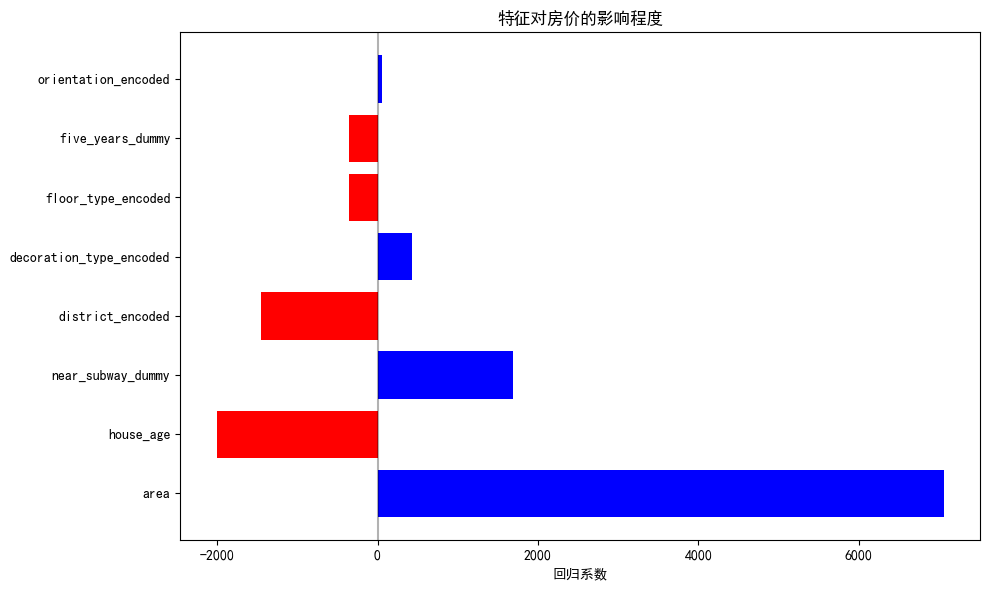

In [16]:
# 使用statsmodels进行详细的回归分析（包含统计检验）
X_sm = sm.add_constant(X_scaled)  # 添加常数项
model_ols = sm.OLS(y, X_sm).fit()

print("="*50)
print("多元线性回归结果 (OLS)")
print("="*50)
print(model_ols.summary())

# 特征重要性可视化
coef_df = pd.DataFrame({
    'feature': ['const'] + features,
    'coefficient': model_ols.params,
    'p_value': model_ols.pvalues
})

# 排除常数项
coef_features = coef_df[coef_df['feature'] != 'const'].sort_values('coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'blue' for x in coef_features['coefficient']]
plt.barh(coef_features['feature'], coef_features['coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('回归系数')
plt.title('特征对房价的影响程度')
plt.tight_layout()
plt.show()

## 机器学习分析

In [17]:
# 比较不同模型
models = {
    'Linear Regression': LinearRegression(),
    'Lasso Regression': Lasso(alpha=0.1),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R2': r2
    }
    
    print(f"{name}:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {np.sqrt(mse):.2f}")
    print(f"  R²: {r2:.4f}")
    print()

# 模型性能比较
results_df = pd.DataFrame(results).T
print("模型性能比较:")
print(results_df)

Linear Regression:
  MSE: 382423834.46
  RMSE: 19555.66
  R²: 0.1373

Lasso Regression:
  MSE: 382423690.91
  RMSE: 19555.66
  R²: 0.1373

Ridge Regression:
  MSE: 382423896.44
  RMSE: 19555.66
  R²: 0.1373

Random Forest:
  MSE: 112978551.41
  RMSE: 10629.14
  R²: 0.7451

模型性能比较:
                            MSE          RMSE        R2
Linear Regression  3.824238e+08  19555.659909  0.137281
Lasso Regression   3.824237e+08  19555.656238  0.137281
Ridge Regression   3.824239e+08  19555.661493  0.137281
Random Forest      1.129786e+08  10629.136908  0.745129


## 随机森林特征重要性分析

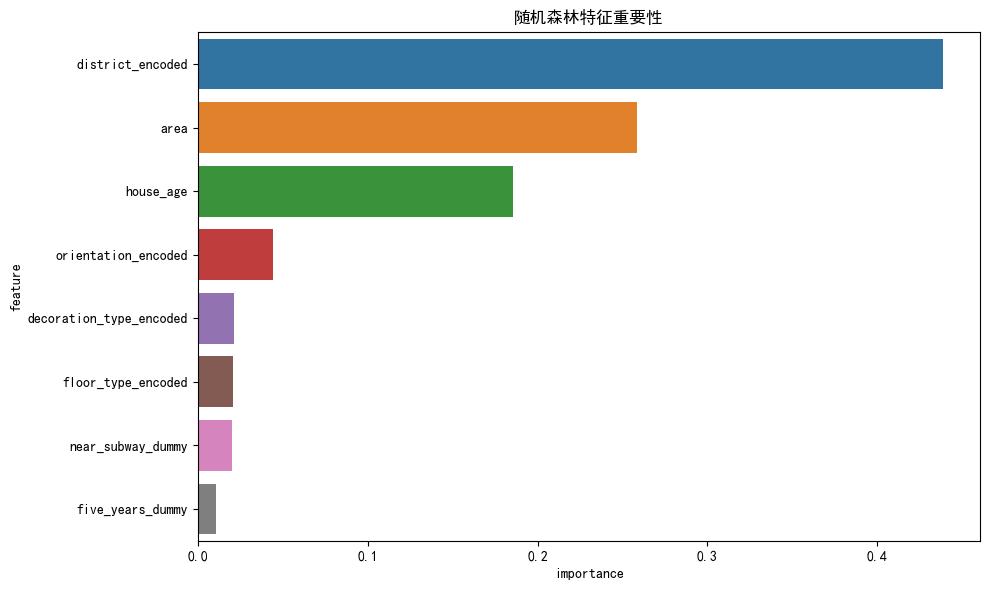

特征重要性排序:
                   feature  importance
4         district_encoded    0.438548
0                     area    0.258799
1                house_age    0.185631
5      orientation_encoded    0.044238
6  decoration_type_encoded    0.021520
7       floor_type_encoded    0.020595
3        near_subway_dummy    0.020124
2         five_years_dummy    0.010546


In [18]:
# 随机森林特征重要性
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('随机森林特征重要性')
plt.tight_layout()
plt.show()

print("特征重要性排序:")
print(feature_importance)

## 模型诊断与残差分析

D:\Program Files\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


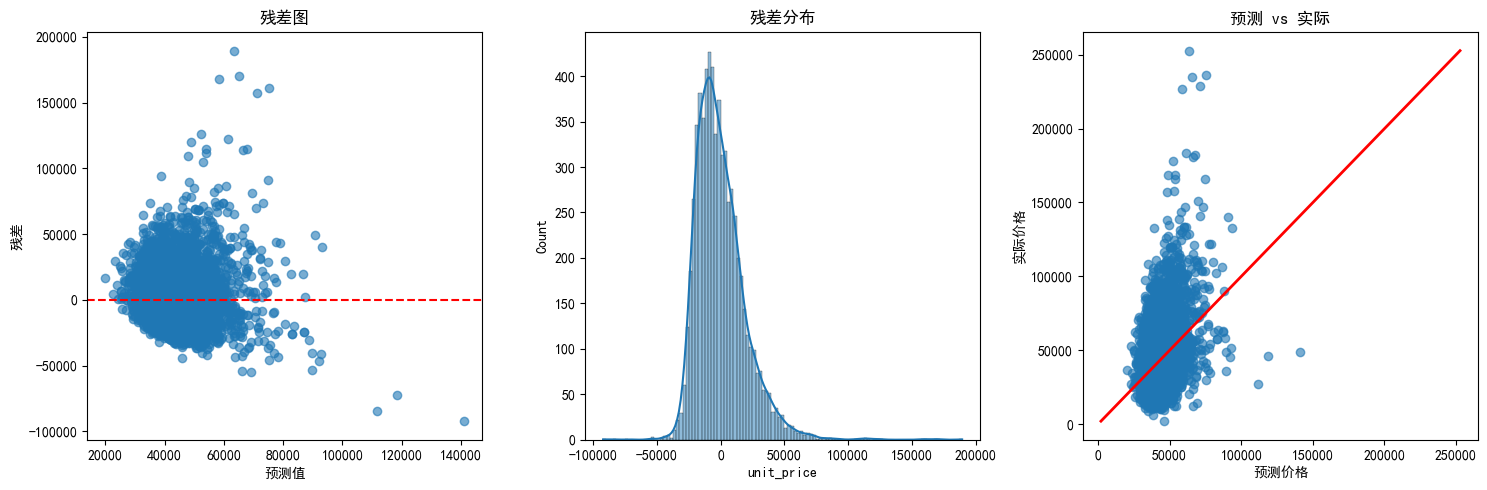

In [19]:
# 使用最佳模型进行预测
best_model = LinearRegression()  # 或者选择表现最好的模型
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# 残差分析
residuals = y_test - y_pred

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.title('残差图')

plt.subplot(1, 3, 2)
sns.histplot(residuals, kde=True)
plt.title('残差分布')

plt.subplot(1, 3, 3)
plt.scatter(y_pred, y_test, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'red', lw=2)
plt.xlabel('预测价格')
plt.ylabel('实际价格')
plt.title('预测 vs 实际')

plt.tight_layout()
plt.show()

# 分时间段分析

## 分类

In [21]:
# 转换成交日期为datetime格式
df_clean['deal_date'] = pd.to_datetime(df_clean['deal_date'])

# 定义时间段分组
def define_time_period(date):
    """根据成交日期定义时间段"""
    if date < pd.Timestamp('2020-01-01'):
        return '疫情前 (2020年前)'
    elif date < pd.Timestamp('2021-06-01'):
        return '疫情初期 (2020-2021.06)'
    elif date < pd.Timestamp('2022-12-01'):
        return '疫情中期 (2021.06-2022.12)'
    else:
        return '疫情后 (2023年及以后)'

# 应用分组
df_clean['time_period'] = df_clean['deal_date'].apply(define_time_period)

print("各时间段样本分布:")
print(df_clean['time_period'].value_counts())

各时间段样本分布:
time_period
疫情后 (2023年及以后)            18786
疫情初期 (2020-2021.06)       10849
疫情中期 (2021.06-2022.12)     7112
疫情前 (2020年前)               3939
Name: count, dtype: int64


## 描述性统计

D:\Program Files\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\Program Files\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


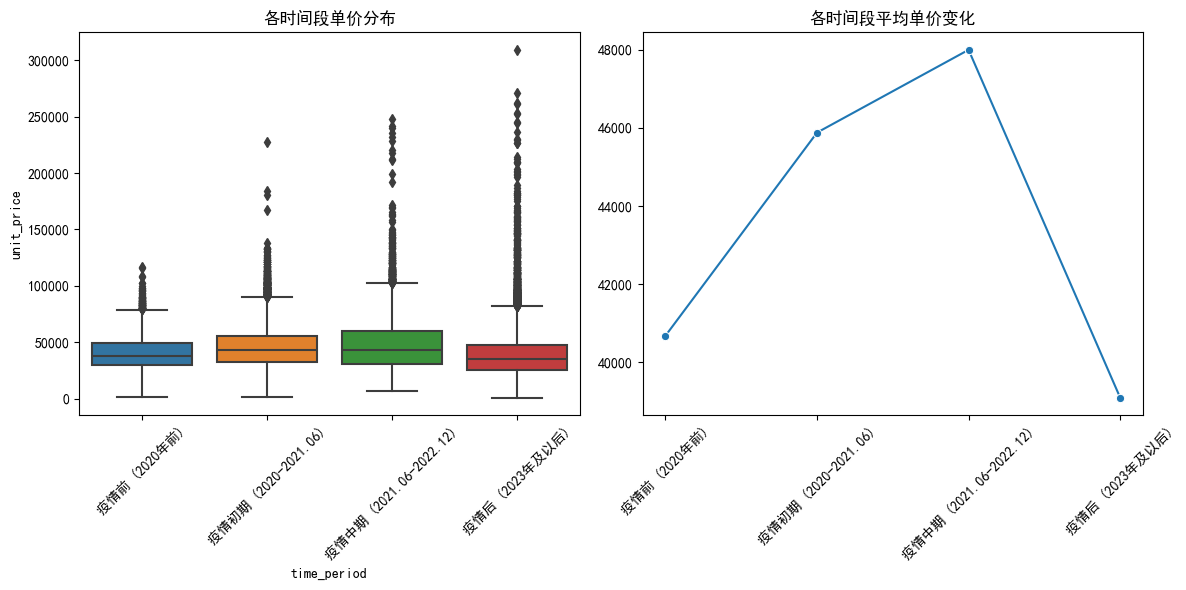

各时间段特征均值:
                             area  near_subway_dummy  five_years_dummy  \
time_period                                                              
疫情前 (2020年前)            72.393012           0.756029          0.304392   
疫情初期 (2020-2021.06)     75.248430           0.762098          0.776477   
疫情中期 (2021.06-2022.12)  74.833567           0.767295          0.858127   
疫情后 (2023年及以后)          79.134254           0.778559          0.759502   

                        house_age  
time_period                        
疫情前 (2020年前)            24.673967  
疫情初期 (2020-2021.06)     23.413995  
疫情中期 (2021.06-2022.12)  23.727740  
疫情后 (2023年及以后)          23.484908  


In [24]:
# 各时间段单价变化
plt.figure(figsize=(12, 6))
time_period_order = ['疫情前 (2020年前)', '疫情初期 (2020-2021.06)', '疫情中期 (2021.06-2022.12)', '疫情后 (2023年及以后)']

plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='time_period', y='unit_price', order=time_period_order)
plt.xticks(rotation=45)
plt.title('各时间段单价分布')

plt.subplot(1, 2, 2)
mean_prices = df_clean.groupby('time_period')['unit_price'].mean().reindex(time_period_order)
sns.lineplot(x=range(len(mean_prices)), y=mean_prices.values, marker='o')
plt.xticks(range(len(mean_prices)), mean_prices.index, rotation=45)
plt.title('各时间段平均单价变化')
plt.tight_layout()
plt.show()

# 各时间段特征均值变化
features_to_compare = ['area', 'near_subway_dummy', 'five_years_dummy', 'house_age']
period_stats = df_clean.groupby('time_period')[features_to_compare].mean().reindex(time_period_order)

print("各时间段特征均值:")
print(period_stats)

## 各时间段回归分析

In [25]:
def prepare_features(df):
    """准备特征数据"""
    feature_df = df.copy()
    
    # 数值特征
    numeric_features = ['area', 'house_age', 'near_subway_dummy', 'five_years_dummy']
    
    # 分类特征编码
    categorical_features = ['district', 'orientation', 'decoration_type', 'floor_type']
    for feature in categorical_features:
        if feature in feature_df.columns:
            le = LabelEncoder()
            feature_df[f'{feature}_encoded'] = le.fit_transform(feature_df[feature].fillna('Unknown'))
            numeric_features.append(f'{feature}_encoded')
    
    return feature_df, numeric_features

def run_period_analysis(df, period_name):
    """对特定时间段进行回归分析"""
    period_df = df[df['time_period'] == period_name].copy()
    
    if len(period_df) < 10:  # 样本太少不分析
        return None, None, None
    
    # 准备特征
    period_df, features = prepare_features(period_df)
    period_df = period_df.dropna(subset=features + ['unit_price'])
    
    if len(period_df) < 5:
        return None, None, None
    
    X = period_df[features]
    y = period_df['unit_price']
    
    # 标准化
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # OLS回归
    X_sm = sm.add_constant(X_scaled)
    model = sm.OLS(y, X_sm).fit()
    
    return model, features, len(period_df)

# 对各时间段分别进行回归分析
period_results = {}
for period in time_period_order:
    model, features, sample_size = run_period_analysis(df_clean, period)
    if model is not None:
        period_results[period] = {
            'model': model,
            'features': features,
            'sample_size': sample_size
        }
        print(f"\n{period} - 样本量: {sample_size}")
        print("R-squared:", model.rsquared)


疫情前 (2020年前) - 样本量: 3606
R-squared: 0.10857316821962537

疫情初期 (2020-2021.06) - 样本量: 9232
R-squared: 0.10456279086843567

疫情中期 (2021.06-2022.12) - 样本量: 5638
R-squared: 0.20296895763113232

疫情后 (2023年及以后) - 样本量: 14279
R-squared: 0.17626300778433823


## 特征重要性随时间变化分析

C:\Users\ading\AppData\Local\Temp\ipykernel_15336\3803096605.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'coefficient': coefs[i],
C:\Users\ading\AppData\Local\Temp\ipykernel_15336\3803096605.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'p_value': p_values[i],
C:\Users\ading\AppData\Local\Temp\ipykernel_15336\3803096605.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'significant': p_values[i] < 0.05
C:\Users\ad

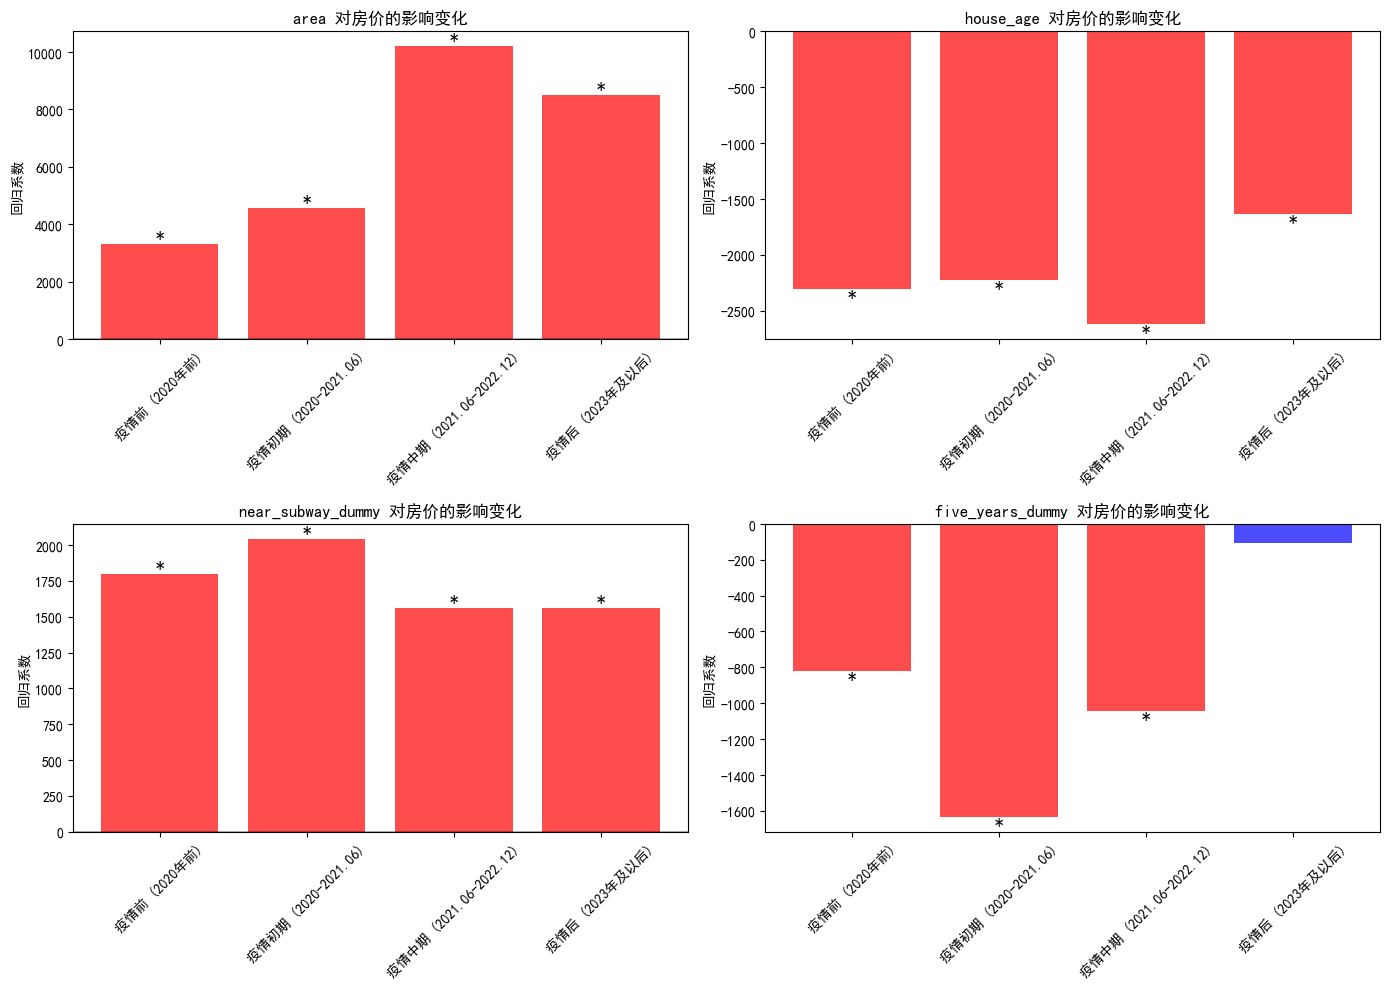

In [31]:
# 提取各时间段的回归系数
coef_comparison = []
feature_names = []

for period, result in period_results.items():
    model = result['model']
    features = result['features']
    
    # 获取系数（排除常数项）
    coefs = model.params[1:1+len(features)]  # 从第1个开始，排除常数项
    p_values = model.pvalues[1:1+len(features)]

    period_num = time_period_order.index(period)
    
    for i, feature in enumerate(features):
        if feature not in ['near_subway_dummy', 'area', 'house_age', 'five_years_dummy']:
            continue  # 只关注关键特征
        
        coef_comparison.append({
            'period': period,
            'period_num': period_num,
            'feature': feature,
            'coefficient': coefs[i],
            'p_value': p_values[i],
            'significant': p_values[i] < 0.05
        })
    
    if not feature_names:
        feature_names = [f for f in features if f in ['near_subway_dummy', 'area', 'house_age', 'five_years_dummy']]

coef_df = pd.DataFrame(coef_comparison)

# 可视化特征系数随时间变化
plt.figure(figsize=(14, 10))

for i, feature in enumerate(feature_names):
    plt.subplot(2, 2, i+1)
    feature_data = coef_df[coef_df['feature'] == feature]
    
    # 按时间段顺序排序
    feature_data['period_num'] = feature_data['period'].map({period: idx for idx, period in enumerate(time_period_order)})
    feature_data = feature_data.sort_values('period_num')
    
    # 绘制系数变化
    colors = ['red' if sig else 'blue' for sig in feature_data['significant']]
    plt.bar(range(len(feature_data)), feature_data['coefficient'], color=colors, alpha=0.7)
    
    # 添加显著性标记
    for j, (idx, row) in enumerate(feature_data.iterrows()):
        if row['significant']:
            plt.text(j, row['coefficient'] + (0.01 if row['coefficient'] > 0 else -0.01), 
                    '*', ha='center', va='bottom' if row['coefficient'] > 0 else 'top', 
                    fontsize=12, fontweight='bold')
    
    plt.xticks(range(len(feature_data)), feature_data['period'], rotation=45)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.title(f'{feature} 对房价的影响变化')
    plt.ylabel('回归系数')

plt.tight_layout()
plt.show()

## 关键特征影响程度对比

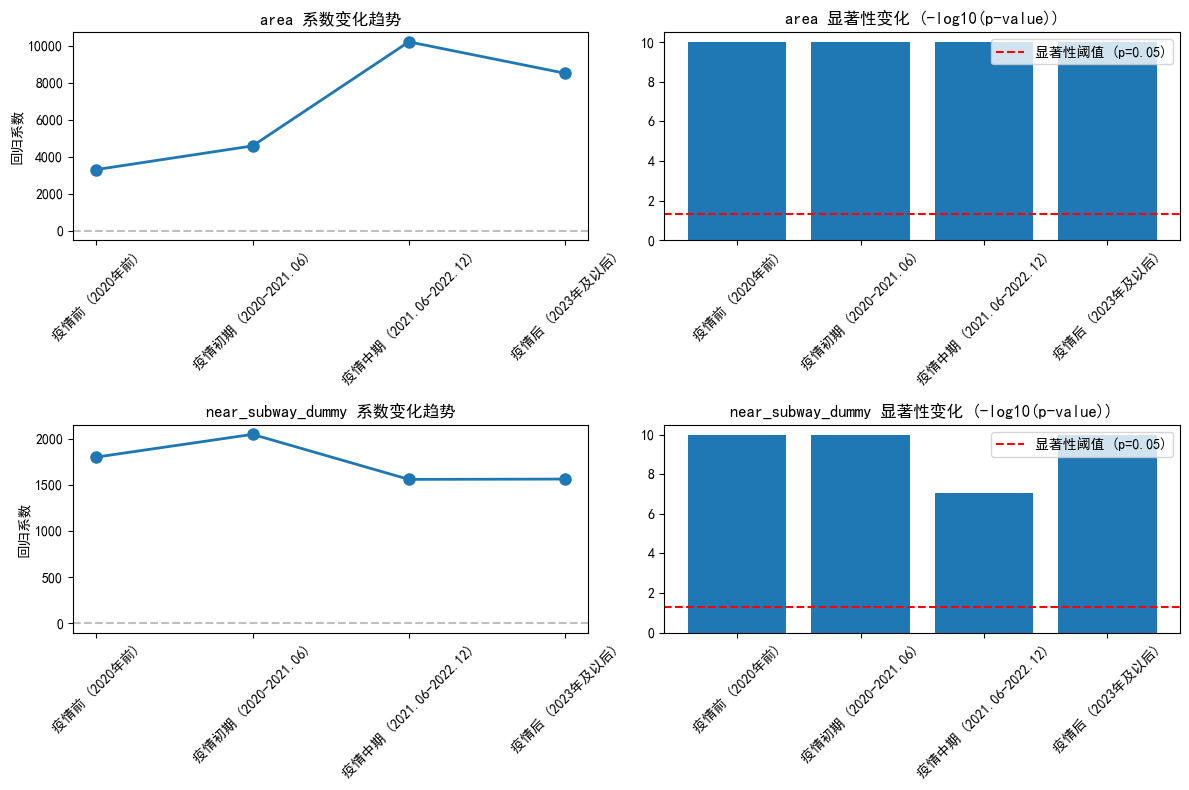

In [32]:
# 重点关注面积和地铁的影响变化
key_features = ['area', 'near_subway_dummy']

plt.figure(figsize=(12, 8))

for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i*2+1)
    
    feature_data = coef_df[coef_df['feature'] == feature]
    feature_data = feature_data.sort_values('period_num')
    
    # 系数变化趋势
    plt.plot(feature_data['period'], feature_data['coefficient'], 'o-', linewidth=2, markersize=8)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.title(f'{feature} 系数变化趋势')
    plt.ylabel('回归系数')
    
    # 显著性变化
    plt.subplot(2, 2, i*2+2)
    plt.bar(feature_data['period'], -np.log10(feature_data['p_value'] + 1e-10))
    plt.axhline(y=-np.log10(0.05), color='red', linestyle='--', label='显著性阈值 (p=0.05)')
    plt.xticks(rotation=45)
    plt.title(f'{feature} 显著性变化 (-log10(p-value))')
    plt.legend()

plt.tight_layout()
plt.show()

## 随机森林重要特征对比

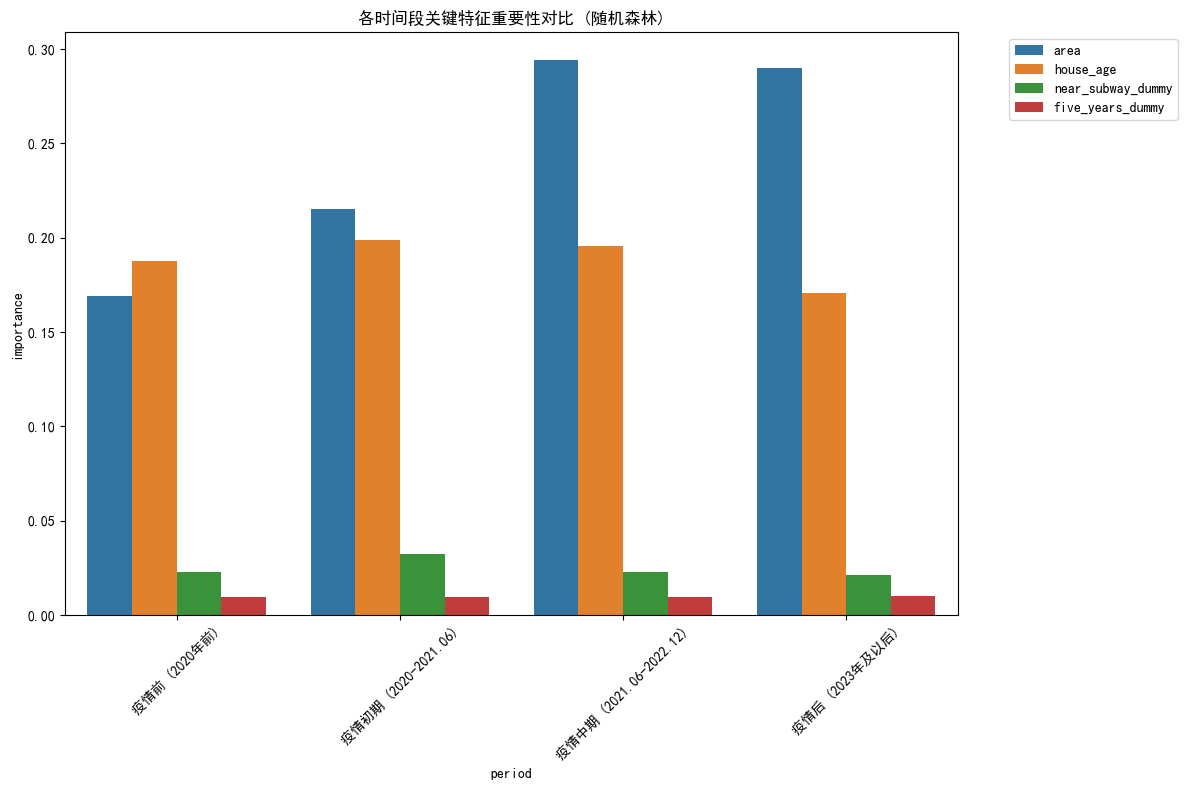

In [33]:
# 使用随机森林分析各时间段的特征重要性
def random_forest_analysis_by_period(df):
    """各时间段的随机森林分析"""
    period_importance = {}
    
    for period in time_period_order:
        period_df = df[df['time_period'] == period].copy()
        
        if len(period_df) < 10:
            continue
            
        # 准备特征
        period_df, features = prepare_features(period_df)
        period_df = period_df.dropna(subset=features + ['unit_price'])
        
        if len(period_df) < 5:
            continue
        
        X = period_df[features]
        y = period_df['unit_price']
        
        # 随机森林
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        
        importance_df = pd.DataFrame({
            'feature': features,
            'importance': rf.feature_importances_,
            'period': period
        })
        
        period_importance[period] = importance_df
    
    return period_importance

# 运行随机森林分析
rf_results = random_forest_analysis_by_period(df_clean)

# 合并结果并可视化关键特征
key_rf_features = []
for period, importance_df in rf_results.items():
    key_features_df = importance_df[importance_df['feature'].isin(['area', 'near_subway_dummy', 'house_age', 'five_years_dummy'])]
    key_rf_features.append(key_features_df)

if key_rf_features:
    rf_comparison = pd.concat(key_rf_features)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=rf_comparison, x='period', y='importance', hue='feature')
    plt.xticks(rotation=45)
    plt.title('各时间段关键特征重要性对比 (随机森林)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## 结果分析报告

In [34]:
# 生成详细的分析报告
print("="*60)
print("不同时期购房偏好变化分析报告")
print("="*60)

for period in time_period_order:
    if period in period_results:
        model = period_results[period]['model']
        sample_size = period_results[period]['sample_size']
        
        print(f"\n{period} (样本量: {sample_size})")
        print(f"模型解释度 (R²): {model.rsquared:.4f}")
        
        # 提取关键特征的系数和显著性
        key_coefs = []
        for feature in ['area', 'near_subway_dummy', 'house_age', 'five_years_dummy']:
            if feature in model.params.index[1:]:  # 排除常数项
                idx = list(model.params.index[1:]).index(feature) + 1
                coef = model.params[idx]
                p_val = model.pvalues[idx]
                significance = "显著" if p_val < 0.05 else "不显著"
                key_coefs.append((feature, coef, p_val, significance))
        
        for feature, coef, p_val, sig in key_coefs:
            feature_name_map = {
                'area': '房屋面积',
                'near_subway_dummy': '近地铁',
                'house_age': '房龄', 
                'five_years_dummy': '满五唯一'
            }
            print(f"  {feature_name_map.get(feature, feature)}: 系数={coef:.4f}, p值={p_val:.4f} ({sig})")

# 总结分析
print("\n" + "="*60)
print("主要发现总结:")
print("="*60)

# 分析面积和地铁影响的趋势
area_trend = coef_df[coef_df['feature'] == 'area'].sort_values('period_num')
subway_trend = coef_df[coef_df['feature'] == 'near_subway_dummy'].sort_values('period_num')

if len(area_trend) > 1:
    area_change = area_trend['coefficient'].iloc[-1] - area_trend['coefficient'].iloc[0]
    print(f"1. 面积对房价的影响变化: {area_change:.4f}")
    if area_change > 0:
        print("   → 购房者对面积的重视程度上升")
    else:
        print("   → 购房者对面积的重视程度下降")

if len(subway_trend) > 1:
    subway_change = subway_trend['coefficient'].iloc[-1] - subway_trend['coefficient'].iloc[0]
    print(f"2. 近地铁对房价的影响变化: {subway_change:.4f}")
    if subway_change > 0:
        print("   → 购房者对地铁便利性的重视程度上升")
    else:
        print("   → 购房者对地铁便利性的重视程度下降")

# 对比疫情前后
if '疫情前 (2020年前)' in period_results and '疫情后 (2023年及以后)' in period_results:
    pre_covid = period_results['疫情前 (2020年前)']['model']
    post_covid = period_results['疫情后 (2023年及以后)']['model']
    
    print("\n3. 疫情前后对比:")
    for feature in ['area', 'near_subway_dummy']:
        if feature in pre_covid.params.index and feature in post_covid.params.index:
            pre_coef = pre_covid.params[feature]
            post_coef = post_covid.params[feature]
            change = post_coef - pre_coef
            print(f"   {feature}: 疫情前={pre_coef:.4f}, 疫情后={post_coef:.4f}, 变化={change:.4f}")

不同时期购房偏好变化分析报告

疫情前 (2020年前) (样本量: 3606)
模型解释度 (R²): 0.1086

疫情初期 (2020-2021.06) (样本量: 9232)
模型解释度 (R²): 0.1046

疫情中期 (2021.06-2022.12) (样本量: 5638)
模型解释度 (R²): 0.2030

疫情后 (2023年及以后) (样本量: 14279)
模型解释度 (R²): 0.1763

主要发现总结:
1. 面积对房价的影响变化: 5208.8194
   → 购房者对面积的重视程度上升
2. 近地铁对房价的影响变化: -238.0538
   → 购房者对地铁便利性的重视程度下降

3. 疫情前后对比:


## 可视化总结

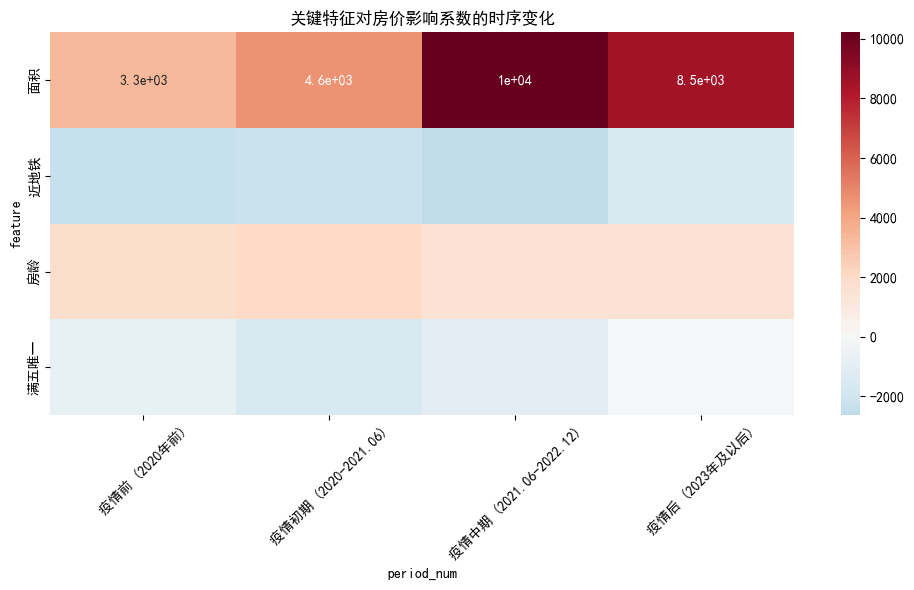

In [35]:
# 创建影响变化热力图
pivot_data = coef_df.pivot_table(
    index='feature', 
    columns='period_num', 
    values='coefficient',
    aggfunc='first'
).reindex(feature_names)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, cmap='RdBu_r', center=0,
            xticklabels=time_period_order, yticklabels=['面积', '近地铁', '房龄', '满五唯一'])
plt.title('关键特征对房价影响系数的时序变化')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 疫情价格提高分析

## 房屋质量

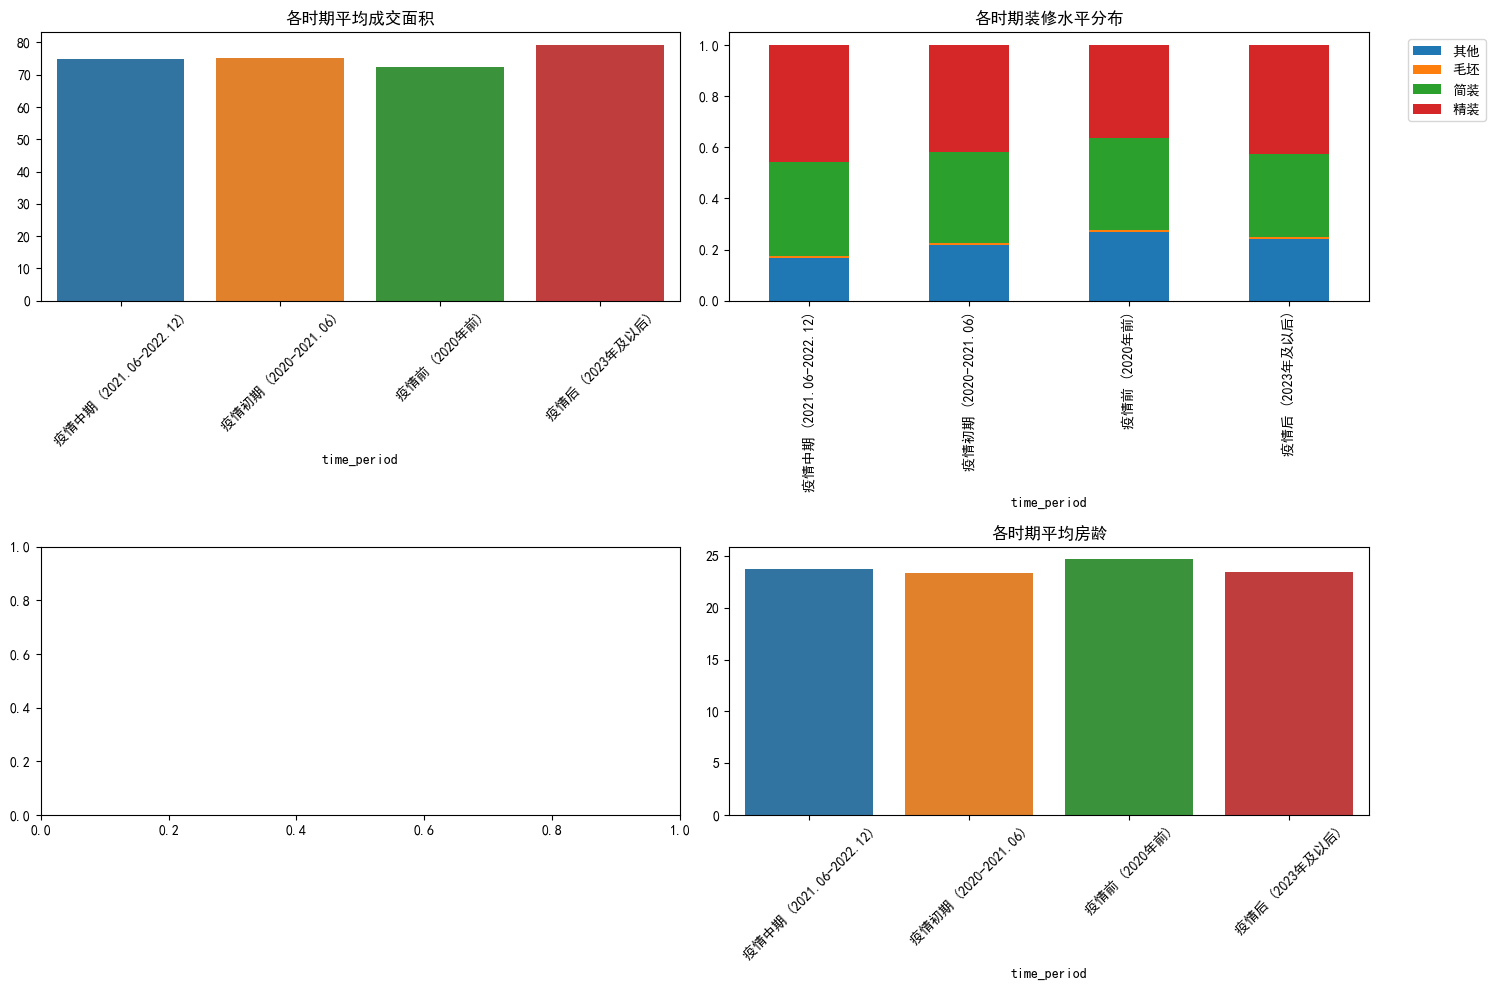

In [40]:
# 分析疫情期间成交房屋的整体质量是否提升
quality_metrics = ['area', 'decoration_type', 'floor_type', 'built_year']

plt.figure(figsize=(15, 10))
for i, metric in enumerate(quality_metrics):
    plt.subplot(2, 2, i+1)
    
    if metric == 'area':
        # 面积变化
        period_means = df_clean.groupby('time_period')[metric].mean()
        sns.barplot(x=period_means.index, y=period_means.values)
        plt.title('各时期平均成交面积')
        plt.xticks(rotation=45)
    
    elif metric == 'decoration_type':
        # 装修水平变化
        decoration_quality = df_clean.groupby(['time_period', metric]).size().unstack(fill_value=0)
        decoration_quality_pct = decoration_quality.div(decoration_quality.sum(axis=1), axis=0)
        decoration_quality_pct.plot(kind='bar', stacked=True, ax=plt.gca())
        plt.title('各时期装修水平分布')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    elif metric == 'built_year':
        # 房龄变化
        df_clean['house_age'] = 2025 - df_clean['built_year']  # 假设当前是2025年
        age_means = df_clean.groupby('time_period')['house_age'].mean()
        sns.barplot(x=age_means.index, y=age_means.values)
        plt.title('各时期平均房龄')
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 区位偏好

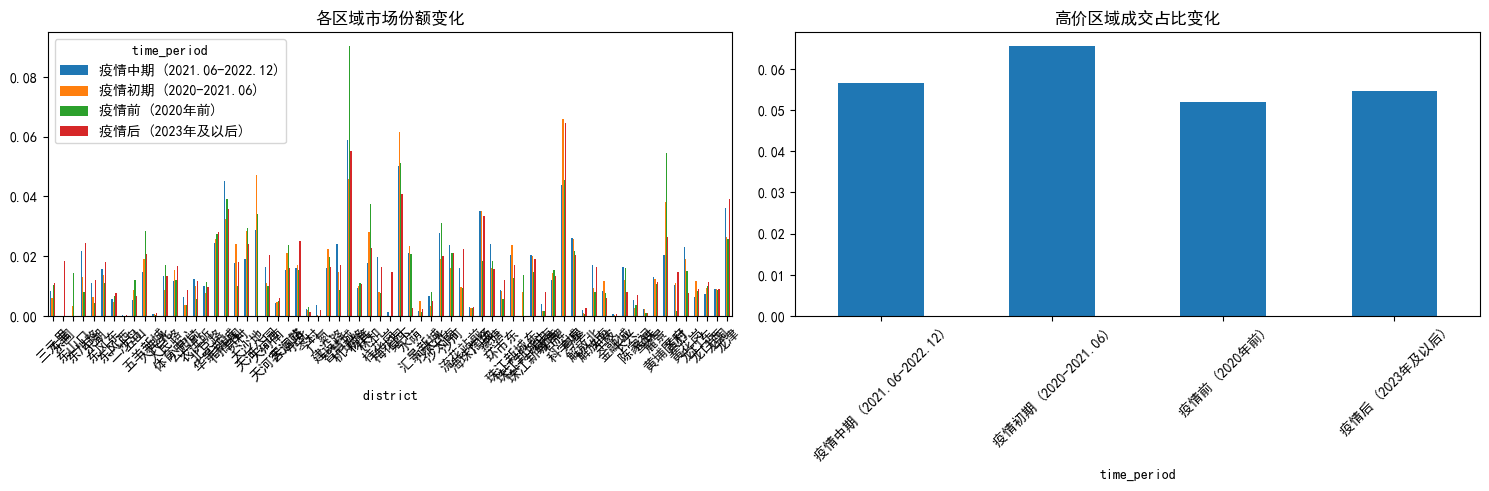

In [41]:
# 分析不同区域的价格变化和成交结构
district_analysis = df_clean.groupby(['time_period', 'district']).agg({
    'unit_price': 'mean',
    'area': 'mean', 
    'near_subway_dummy': 'mean',
    'total_price': 'mean'
}).reset_index()

# 计算各区域市场份额变化
district_share = df_clean.groupby(['time_period', 'district']).size().unstack(fill_value=0)
district_share_pct = district_share.div(district_share.sum(axis=1), axis=0)

plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
district_share_pct.T.plot(kind='bar', ax=plt.gca())
plt.title('各区域市场份额变化')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
# 高价区域成交占比变化
high_price_districts = df_clean.groupby('district')['unit_price'].mean().nlargest(5).index
high_price_share = df_clean[df_clean['district'].isin(high_price_districts)]
high_price_share_pct = high_price_share.groupby('time_period').size() / df_clean.groupby('time_period').size()
high_price_share_pct.plot(kind='bar', ax=plt.gca())
plt.title('高价区域成交占比变化')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 稀缺性溢价

市场热度指标:
                       unit_price            deal_cycle_days list_price  \
                             mean        std            mean       mean   
time_period                                                               
疫情中期 (2021.06-2022.12)  47996.913  23717.474         140.594    413.859   
疫情初期 (2020-2021.06)     45877.782  18787.875         146.287    374.794   
疫情前 (2020年前)            40676.240  15301.678         119.742    320.716   
疫情后 (2023年及以后)          39092.965  20408.037         212.865    373.911   

                       total_price price_gap  
                              mean      mean  
time_period                                   
疫情中期 (2021.06-2022.12)     392.985     0.040  
疫情初期 (2020-2021.06)        360.239     0.035  
疫情前 (2020年前)               305.853     0.043  
疫情后 (2023年及以后)             338.105     0.090  


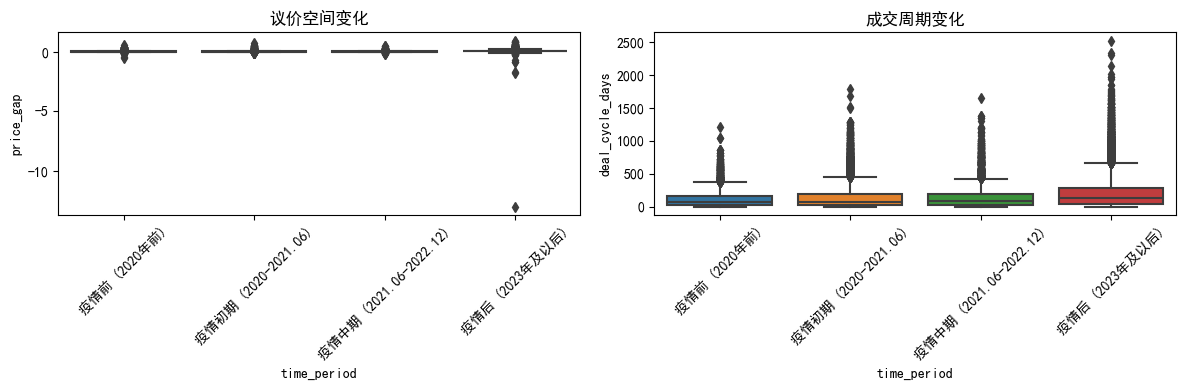

In [44]:
# 挂牌价与成交价差距分析
df_clean['price_gap'] = (df_clean['list_price'] - df_clean['total_price']) / df_clean['list_price']


# 分析供应量减少导致的稀缺性溢价
supply_demand_analysis = df_clean.groupby('time_period').agg({
    'unit_price': ['mean', 'std'],
    'deal_cycle_days': 'mean',  # 成交周期反映市场热度
    'list_price': 'mean',
    'total_price': 'mean',
    'price_gap': 'mean'
}).round(3)

print("市场热度指标:")
print(supply_demand_analysis)



plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_clean, x='time_period', y='price_gap', order=time_period_order)
plt.xticks(rotation=45)
plt.title('议价空间变化')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_clean, x='time_period', y='deal_cycle_days', order=time_period_order)
plt.xticks(rotation=45)
plt.title('成交周期变化')
plt.tight_layout()
plt.show()

## 投资属性

<Figure size 1200x600 with 0 Axes>

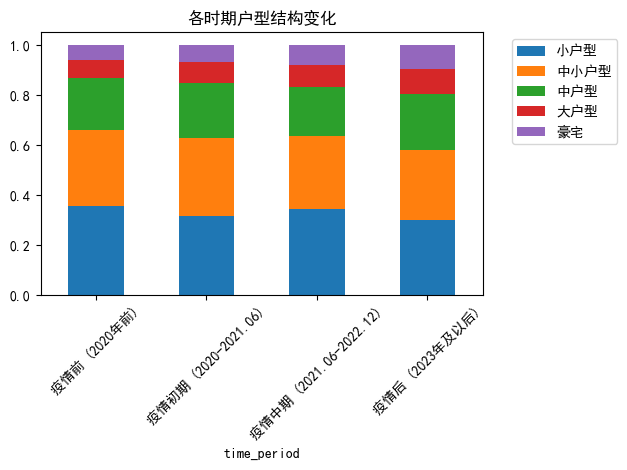

大户型相对小户型的溢价倍数:
time_period
疫情前 (2020年前)              1.331902
疫情初期 (2020-2021.06)       1.326150
疫情中期 (2021.06-2022.12)    1.616936
疫情后 (2023年及以后)            1.546815
Name: unit_price, dtype: float64


In [47]:
# 分析大户型（投资属性更强）的成交变化
df_clean['size_category'] = pd.cut(df_clean['area'], 
                                     bins=[0, 60, 80, 100, 120, 1000],
                                     labels=['小户型', '中小户型', '中户型', '大户型', '豪宅'])

size_trend = pd.crosstab(df_clean['time_period'], df_clean['size_category'], normalize='index')

plt.figure(figsize=(12, 6))
size_trend.loc[time_period_order].plot(kind='bar', stacked=True)
plt.title('各时期户型结构变化')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 大户型溢价变化
large_apt_premium = df_clean[df_clean['size_category'].isin(['大户型', '豪宅'])].groupby('time_period')['unit_price'].mean()
small_apt_premium = df_clean[df_clean['size_category'].isin(['小户型', '中小户型'])].groupby('time_period')['unit_price'].mean()

premium_ratio = (large_apt_premium / small_apt_premium).reindex(time_period_order)
print("大户型相对小户型的溢价倍数:")
print(premium_ratio)

## 多因素回归

In [46]:
# 控制其他因素后，看面积效应的真实变化
def enhanced_regression_analysis(df):
    """控制更多变量后的回归分析"""
    results = {}
    
    for period in time_period_order:
        period_df = df[df['time_period'] == period].copy()
        
        if len(period_df) < 10:
            continue
            
        # 准备更多特征
        period_df, base_features = prepare_features(period_df)
        
        # 添加更多控制变量
        additional_features = []
        
        # 区域固定效应
        district_dummies = pd.get_dummies(period_df['district'], prefix='district')
        period_df = pd.concat([period_df, district_dummies], axis=1)
        additional_features.extend(district_dummies.columns)
        
        # 户型分类
        if 'size_category' in period_df.columns:
            size_dummies = pd.get_dummies(period_df['size_category'], prefix='size')
            period_df = pd.concat([period_df, size_dummies], axis=1)
            additional_features.extend(size_dummies.columns)
        
        # 装修水平
        if 'decoration_type' in period_df.columns:
            decoration_dummies = pd.get_dummies(period_df['decoration_type'], prefix='decoration')
            period_df = pd.concat([period_df, decoration_dummies], axis=1)
            additional_features.extend(decoration_dummies.columns)
        
        all_features = base_features + additional_features
        period_df = period_df.dropna(subset=all_features + ['unit_price'])
        
        if len(period_df) < 5:
            continue
        
        X = period_df[all_features]
        y = period_df['unit_price']
        
        # 标准化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # OLS回归
        X_sm = sm.add_constant(X_scaled)
        model = sm.OLS(y, X_sm).fit()
        
        results[period] = {
            'model': model,
            'features': all_features,
            'sample_size': len(period_df)
        }
    
    return results

# 运行增强版回归
enhanced_results = enhanced_regression_analysis(df_clean)

# 提取面积系数变化
area_coef_enhanced = []
for period, result in enhanced_results.items():
    model = result['model']
    features = result['features']
    
    if 'area' in features:
        idx = features.index('area') + 1  # +1 for constant
        coef = model.params[idx]
        p_val = model.pvalues[idx]
        
        area_coef_enhanced.append({
            'period': period,
            'coefficient': coef,
            'p_value': p_val,
            'significant': p_val < 0.05,
            'model': 'enhanced'
        })

# 与基础模型对比
area_comparison = pd.DataFrame(area_coef_enhanced)
print("控制更多变量后的面积效应:")
print(area_comparison[['period', 'coefficient', 'p_value', 'significant']])

控制更多变量后的面积效应:
                   period  coefficient       p_value  significant
0            疫情前 (2020年前)  -599.263080  1.560785e-01        False
1     疫情初期 (2020-2021.06)  1370.379958  1.732265e-04         True
2  疫情中期 (2021.06-2022.12)  4463.411712  8.476551e-13         True
3          疫情后 (2023年及以后)  2423.185659  9.553025e-12         True


C:\Users\ading\AppData\Local\Temp\ipykernel_15336\2318492218.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = model.params[idx]
C:\Users\ading\AppData\Local\Temp\ipykernel_15336\2318492218.py:72: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p_val = model.pvalues[idx]
C:\Users\ading\AppData\Local\Temp\ipykernel_15336\2318492218.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coef = model.params[idx]
C:\Users\ading\Ap

## 价格分解

In [49]:
# 价格变化的分解分析
def price_decomposition(df):
    """分解价格变化的来源"""
    decomposition = []
    
    for i in range(len(time_period_order)-1):
        period1 = time_period_order[i]
        period2 = time_period_order[i+1]
        
        df1 = df[df['time_period'] == period1]
        df2 = df[df['time_period'] == period2]
        
        if len(df1) == 0 or len(df2) == 0:
            continue
            
        # 计算价格变化
        price_change = df2['unit_price'].mean() - df1['unit_price'].mean()
        
        # 特征变化导致的價格變化
        feature_changes = {}
        for feature in ['area', 'house_age', 'near_subway_dummy', 'five_years_dummy']:
            if feature in df1.columns and feature in df2.columns:
                feature_change = df2[feature].mean() - df1[feature].mean()
                # 使用平均系数估算影响
                avg_coef = (df1[feature].corr(df1['unit_price']) + df2[feature].corr(df2['unit_price'])) / 2
                feature_effect = feature_change * avg_coef * df1['unit_price'].mean()
                feature_changes[feature] = feature_effect
        
        # 残差（无法由特征变化解释的部分）
        explained_change = sum(feature_changes.values())
        residual_change = price_change - explained_change
        
        decomposition.append({
            'period_pair': f'{period1}→{period2}',
            'total_change': price_change,
            'area_effect': feature_changes.get('area', 0),
            'other_features_effect': explained_change - feature_changes.get('area', 0),
            'residual_effect': residual_change
        })
    
    return pd.DataFrame(decomposition)

decomp_results = price_decomposition(df_clean)
print("价格变化分解:")
print(decomp_results)

价格变化分解:
                                  period_pair  total_change   area_effect  \
0            疫情前 (2020年前)→疫情初期 (2020-2021.06)   5201.542261  27785.670984   
1  疫情初期 (2020-2021.06)→疫情中期 (2021.06-2022.12)   2119.131049  -6120.224692   
2       疫情中期 (2021.06-2022.12)→疫情后 (2023年及以后)  -8903.947724  80643.124735   

   other_features_effect  residual_effect  
0            5907.073666    -28491.202390  
1           -2069.348671     10308.704411  
2            1695.606296    -91242.678755  


# 大小户型分析

## 户型结构变化

<Figure size 1200x600 with 0 Axes>

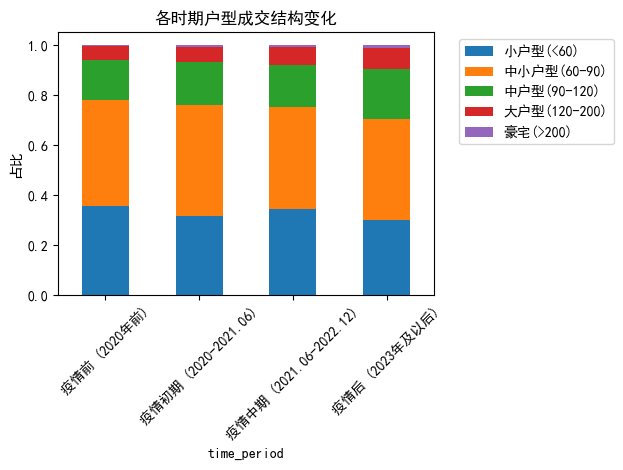

各时期户型分布:
size_category           小户型(<60)  中小户型(60-90)  中户型(90-120)  大户型(120-200)  \
time_period                                                                
疫情前 (2020年前)               0.357        0.424        0.160         0.054   
疫情初期 (2020-2021.06)        0.316        0.444        0.172         0.060   
疫情中期 (2021.06-2022.12)     0.343        0.410        0.166         0.072   
疫情后 (2023年及以后)             0.298        0.405        0.199         0.085   

size_category           豪宅(>200)  
time_period                       
疫情前 (2020年前)               0.006  
疫情初期 (2020-2021.06)        0.008  
疫情中期 (2021.06-2022.12)     0.009  
疫情后 (2023年及以后)             0.013  


In [56]:
# 创建户型分类
df_clean['size_category'] = pd.cut(df_clean['area'], 
                                     bins=[0, 60, 90, 120, 200, 1000],
                                     labels=['小户型(<60)', '中小户型(60-90)', '中户型(90-120)', '大户型(120-200)', '豪宅(>200)'])

# 各时期户型分布变化
size_distribution = pd.crosstab(df_clean['time_period'], df_clean['size_category'], 
                                normalize='index').reindex(time_period_order)

plt.figure(figsize=(12, 6))
size_distribution.plot(kind='bar', stacked=True)
plt.title('各时期户型成交结构变化')
plt.ylabel('占比')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("各时期户型分布:")
print(size_distribution.round(3))

## 总价分析与购买力

C:\Users\ading\AppData\Local\Temp\ipykernel_15336\1126037442.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  price_by_size_period = df_clean.groupby(['time_period', 'size_category']).agg({


各时期不同户型的平均总价:
                                     total_price       unit_price
                                            mean count       mean
time_period            size_category                             
疫情前 (2020年前)           小户型(<60)           167.12  1406   38119.94
                       中小户型(60-90)        293.51  1668   39239.13
                       中户型(90-120)        460.38   630   45326.45
                       大户型(120-200)       753.98   212   53456.30
                       豪宅(>200)          1370.18    22   57263.91
疫情初期 (2020-2021.06)    小户型(<60)           185.71  3427   42375.73
                       中小户型(60-90)        332.09  4813   44256.15
                       中户型(90-120)        511.36  1863   50119.58
                       大户型(120-200)       898.90   656   62482.02
                       豪宅(>200)          1456.75    90   57117.63
疫情中期 (2021.06-2022.12) 小户型(<60)           175.70  2438   40347.64
                       中小户型(60-90)        341.62  2918   45611

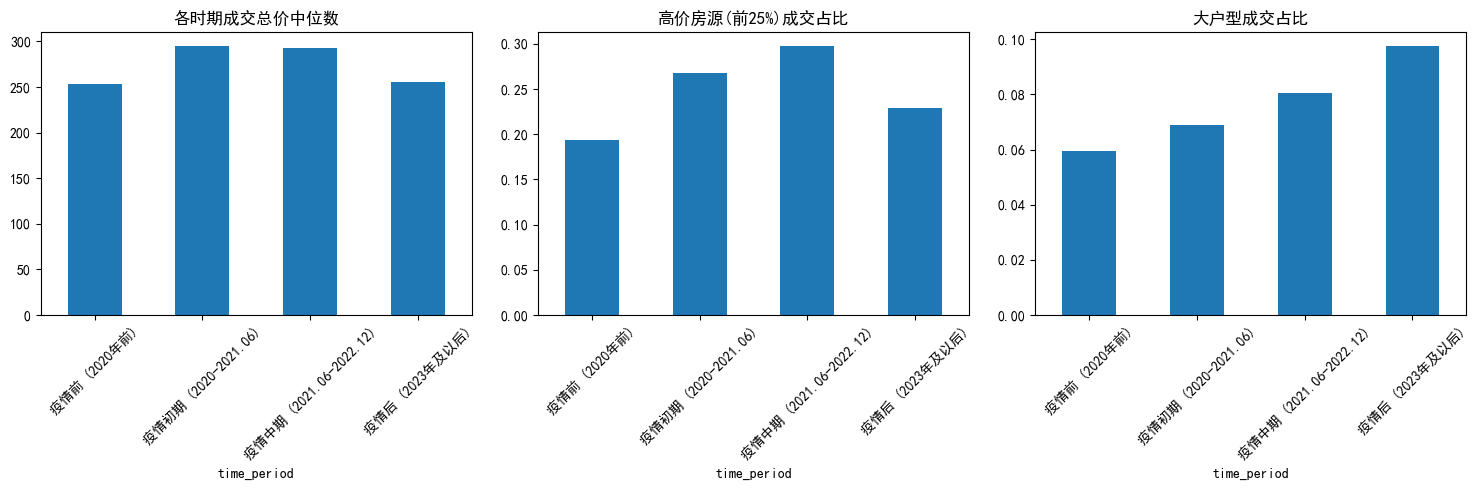

In [57]:
# 分析各时期不同户型的平均总价
price_by_size_period = df_clean.groupby(['time_period', 'size_category']).agg({
    'total_price': ['mean', 'count'],
    'unit_price': 'mean'
}).round(2).reindex(time_period_order, level=0)

print("各时期不同户型的平均总价:")
print(price_by_size_period)

# 总价分布变化
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# 各时期总价中位数
median_total_price = df_clean.groupby('time_period')['total_price'].median().reindex(time_period_order)
median_total_price.plot(kind='bar')
plt.title('各时期成交总价中位数')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
# 高价房源占比变化 (比如总价前25%)
price_threshold = df_clean['total_price'].quantile(0.75)
high_price_share = df_clean.groupby('time_period')['total_price'].apply(
    lambda x: (x > price_threshold).mean()
).reindex(time_period_order)
high_price_share.plot(kind='bar')
plt.title('高价房源(前25%)成交占比')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
# 大户型占比变化
large_share = df_clean.groupby('time_period')['size_category'].apply(
    lambda x: x.isin(['大户型(120-200)', '豪宅(>200)']).mean()
).reindex(time_period_order)
large_share.plot(kind='bar')
plt.title('大户型成交占比')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 购买力指标

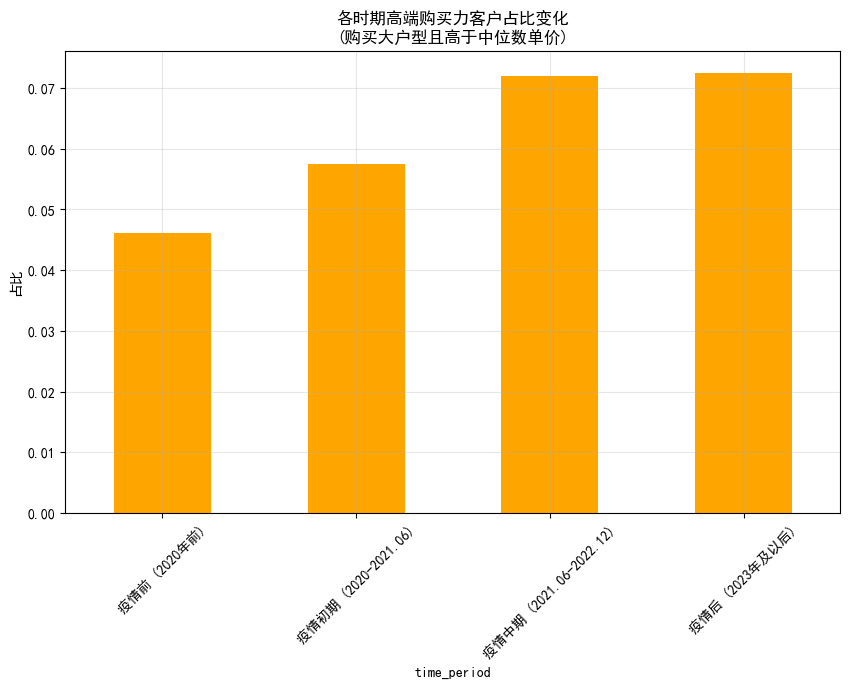

高端购买力客户占比:
time_period
疫情前 (2020年前)              0.046
疫情初期 (2020-2021.06)       0.058
疫情中期 (2021.06-2022.12)    0.072
疫情后 (2023年及以后)            0.073
Name: premium_indicator, dtype: float64


In [58]:
# 创建购买力代理指标
# 假设：购买大户型且单价高的客户更有钱
df_clean['premium_indicator'] = (df_clean['size_category'].isin(['大户型(120-200)', '豪宅(>200)'])) & \
                                   (df_clean['unit_price'] > df_clean['unit_price'].median())

# 各时期高端购买力变化
premium_share = df_clean.groupby('time_period')['premium_indicator'].mean().reindex(time_period_order)

plt.figure(figsize=(10, 6))
premium_share.plot(kind='bar', color='orange')
plt.title('各时期高端购买力客户占比变化\n(购买大户型且高于中位数单价)')
plt.ylabel('占比')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

print("高端购买力客户占比:")
print(premium_share.round(3))

## 价格面积分析

各时期面积与总价相关性:
                   period  correlation  p_value  sample_size
0            疫情前 (2020年前)     0.810635      0.0         3938
1     疫情初期 (2020-2021.06)     0.770112      0.0        10849
2  疫情中期 (2021.06-2022.12)     0.760240      0.0         7112
3          疫情后 (2023年及以后)     0.723187      0.0        18786


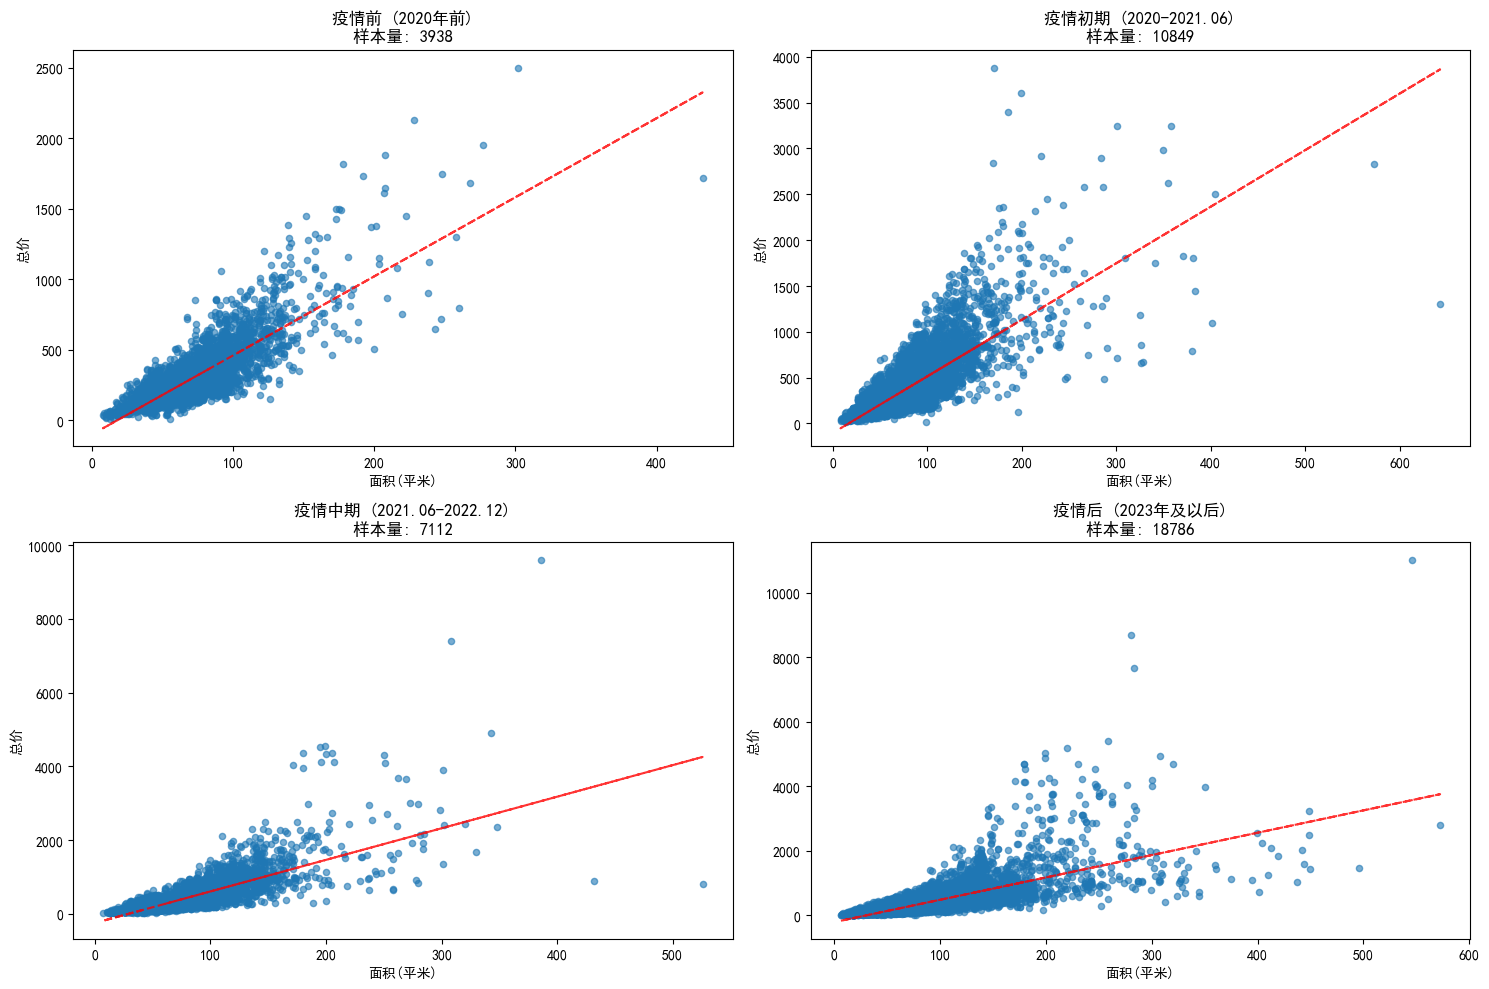

In [64]:
# 修改价格-面积关系分析部分
from scipy.stats import pearsonr

# 计算各时期价格与面积的相关性
correlation_by_period = []
for period in time_period_order:
    period_data = df_clean[df_clean['time_period'] == period]
    
    # 清理数据：移除缺失值和无穷值
    clean_data = period_data[['area', 'total_price']].dropna()
    clean_data = clean_data[np.isfinite(clean_data['area'])]
    clean_data = clean_data[np.isfinite(clean_data['total_price'])]
    
    if len(clean_data) > 10:
        corr, p_value = pearsonr(clean_data['area'], clean_data['total_price'])
        correlation_by_period.append({
            'period': period,
            'correlation': corr,
            'p_value': p_value,
            'sample_size': len(clean_data)
        })

corr_df = pd.DataFrame(correlation_by_period)
print("各时期面积与总价相关性:")
print(corr_df)

# 可视化价格-面积散点图（同样需要清理数据）
plt.figure(figsize=(15, 10))
for i, period in enumerate(time_period_order):
    plt.subplot(2, 2, i+1)
    period_data = df_clean[df_clean['time_period'] == period]
    
    # 清理数据
    clean_data = period_data[['area', 'total_price']].dropna()
    clean_data = clean_data[np.isfinite(clean_data['area'])]
    clean_data = clean_data[np.isfinite(clean_data['total_price'])]
    
    if len(clean_data) > 0:
        plt.scatter(clean_data['area'], clean_data['total_price'], alpha=0.6, s=20)
        plt.title(f'{period}\n样本量: {len(clean_data)}')
        plt.xlabel('面积(平米)')
        plt.ylabel('总价')
        if len(clean_data) > 10:
            # 添加趋势线
            z = np.polyfit(clean_data['area'], clean_data['total_price'], 1)
            p = np.poly1d(z)
            plt.plot(clean_data['area'], p(clean_data['area']), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

## 客户分层

各时期不同价格区间的户型偏好:
size_category                         小户型(<60)  中小户型(60-90)  中户型(90-120)  \
time_period            price_segment                                       
疫情中期 (2021.06-2022.12) 低价位               0.838        0.159        0.002   
                       中低价位              0.423        0.522        0.053   
                       中高价位              0.199        0.611        0.175   
                       高价位               0.020        0.351        0.372   
疫情初期 (2020-2021.06)    低价位               0.848        0.145        0.007   
                       中低价位              0.420        0.527        0.050   
                       中高价位              0.159        0.653        0.177   
                       高价位               0.019        0.341        0.397   
疫情前 (2020年前)           低价位               0.844        0.153        0.002   
                       中低价位              0.356        0.570        0.072   
                       中高价位              0.144        0.646        0.197

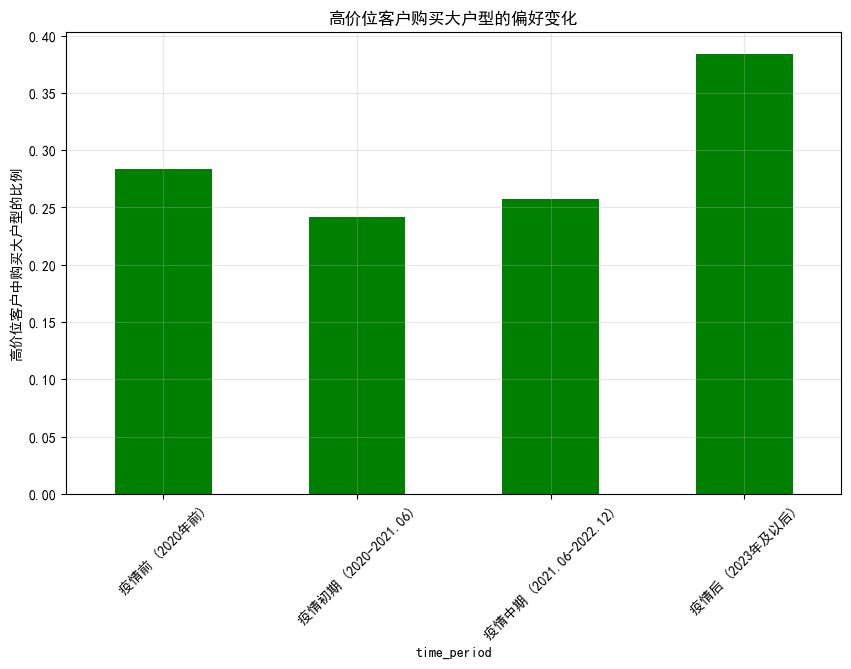

In [60]:
# 按总价将客户分层
df_clean['price_segment'] = pd.qcut(df_clean['total_price'], q=4, 
                                      labels=['低价位', '中低价位', '中高价位', '高价位'])

# 分析各价格区间的户型偏好变化
segment_size_analysis = pd.crosstab(
    [df_clean['time_period'], df_clean['price_segment']],
    df_clean['size_category'],
    normalize='index'
).round(3)

print("各时期不同价格区间的户型偏好:")
print(segment_size_analysis)

# 高价位客户的大户型偏好变化
high_end_preference = segment_size_analysis.xs('高价位', level=1)
large_apt_preference = high_end_preference[['大户型(120-200)', '豪宅(>200)']].sum(axis=1).reindex(time_period_order)

plt.figure(figsize=(10, 6))
large_apt_preference.plot(kind='bar', color='green')
plt.title('高价位客户购买大户型的偏好变化')
plt.ylabel('高价位客户中购买大户型的比例')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

## 统计检验

In [61]:
from scipy.stats import chi2_contingency, ttest_ind

# 卡方检验：户型分布在疫情前后是否有显著差异
pre_covid_data = df_clean[df_clean['time_period'] == '疫情前 (2020年前)']
post_covid_data = df_clean[df_clean['time_period'] == '疫情后 (2023年及以后)']

if len(pre_covid_data) > 0 and len(post_covid_data) > 0:
    # 创建列联表
    contingency_table = pd.crosstab(
        pd.concat([pre_covid_data['time_period'], post_covid_data['time_period']]),
        pd.concat([pre_covid_data['size_category'], post_covid_data['size_category']])
    )
    
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    print(f"户型分布变化的卡方检验:")
    print(f"卡方值: {chi2:.3f}, p值: {p_value:.3f}")
    print("户型分布在疫情前后有显著差异" if p_value < 0.05 else "户型分布在疫情前后无显著差异")

# T检验：平均面积是否有显著变化
if len(pre_covid_data) > 0 and len(post_covid_data) > 0:
    t_stat, p_value = ttest_ind(pre_covid_data['area'].dropna(), 
                               post_covid_data['area'].dropna(),
                               equal_var=False)
    print(f"\n平均面积变化的T检验:")
    print(f"T统计量: {t_stat:.3f}, p值: {p_value:.3f}")
    print("平均面积在疫情前后有显著差异" if p_value < 0.05 else "平均面积在疫情前后无显著差异")

户型分布变化的卡方检验:
卡方值: 120.071, p值: 0.000
户型分布在疫情前后有显著差异

平均面积变化的T检验:
T统计量: -12.004, p值: 0.000
平均面积在疫情前后有显著差异


## 关键指标

In [62]:
# 计算关键验证指标
validation_metrics = df_clean.groupby('time_period').agg({
    'area': 'mean',
    'total_price': 'mean',
    'size_category': lambda x: (x.isin(['大户型(120-200)', '豪宅(>200)'])).mean(),
    'unit_price': 'mean'
}).reindex(time_period_order).round(2)

validation_metrics['大户型占比(%)'] = validation_metrics['size_category'] * 100
validation_metrics['平均总价(万)'] = validation_metrics['total_price']
validation_metrics['平均面积(平米)'] = validation_metrics['area']

print("验证假设的关键指标:")
print(validation_metrics[['平均面积(平米)', '平均总价(万)', '大户型占比(%)']])

验证假设的关键指标:
                        平均面积(平米)  平均总价(万)  大户型占比(%)
time_period                                        
疫情前 (2020年前)               72.39   305.85       6.0
疫情初期 (2020-2021.06)        75.25   360.24       7.0
疫情中期 (2021.06-2022.12)     74.83   392.98       8.0
疫情后 (2023年及以后)             79.13   338.11      10.0


# 实证产业组织

## 数据准备

In [67]:
# 数据准备
def prepare_io_data(df):
    """准备产业组织分析所需数据"""
    df_io = df.copy()
    
    # 创建市场定义（时间-区域）
    df_io['market'] = df_io['time_period'] + '_' + df_io['district']
    
    # 创建产品特征
    df_io['log_area'] = np.log(df_io['area'])
    df_io['log_price'] = np.log(df_io['unit_price'])
    
    # 创建产品id
    df_io['product_id'] = df_io.groupby(['district', 'layout', 'area']).ngroup()
    
    return df_io

df_io = prepare_io_data(df_clean)
print(f"市场数量: {df_io['market'].nunique()}")
print(f"产品数量: {df_io['product_id'].nunique()}")

市场数量: 255
产品数量: 30309


## 市场集中度与产品多样性

In [68]:
# 计算各市场的HHI指数和产品多样性
market_analysis = df_io.groupby('market').agg({
    'product_id': ['count', 'nunique'],  # 交易量、产品种类
    'unit_price': ['mean', 'std'],
    'area': ['mean', 'std'],
    'total_price': 'sum'
}).round(2)

market_analysis.columns = ['交易量', '产品种类', '均价', '价格标准差', '平均面积', '面积标准差', '总交易额']
market_analysis['HHI'] = df_io.groupby('market').apply(
    lambda x: (x['product_id'].value_counts(normalize=True) ** 2).sum() * 10000
)

print("市场结构分析:")
print(market_analysis.sort_values('HHI', ascending=False).head(10))

市场结构分析:
                            交易量  产品种类         均价     价格标准差    平均面积   面积标准差  \
market                                                                       
疫情初期 (2020-2021.06)_二沙岛       1     1  108786.00       NaN  213.54     NaN   
疫情前 (2020年前)_人民北              1     1   42308.00       NaN   65.00     NaN   
疫情前 (2020年前)_解放北              2     2   36630.50   4934.90   69.28   38.58   
疫情中期 (2021.06-2022.12)_二沙岛    2     2  108426.00   3177.74  250.00   42.43   
疫情中期 (2021.06-2022.12)_金融城    4     3   81393.00   5281.93   97.66   11.67   
疫情后 (2023年及以后)_二沙岛            3     3  146339.33  47738.39  307.58  206.61   
疫情初期 (2020-2021.06)_金融城       4     4   84156.75   9842.04   74.59    5.60   
疫情前 (2020年前)_鱼珠               4     4   28696.75   5637.89   59.59   11.93   
疫情中期 (2021.06-2022.12)_人民北    4     4   35172.50   9908.84   88.02   32.34   
疫情初期 (2020-2021.06)_广氮        5     5   61121.80  14751.68   87.56   42.04   

                               总交易额           HHI  
mar

C:\Users\ading\AppData\Local\Temp\ipykernel_15336\2615311617.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  market_analysis['HHI'] = df_io.groupby('market').apply(


## 简化需求估计

In [69]:
class SimpleDemandModel:
    """简化版需求估计模型"""
    
    def __init__(self):
        self.results = {}
    
    def calculate_market_shares(self, df):
        """计算市场份额"""
        market_data = []
        
        for market in df['market'].unique():
            market_df = df[df['market'] == market]
            total_transactions = len(market_df)
            
            # 计算每个产品的市场份额
            product_shares = market_df['product_id'].value_counts(normalize=True)
            
            for product_id, share in product_shares.items():
                product_data = market_df[market_df['product_id'] == product_id].iloc[0]
                market_data.append({
                    'market': market,
                    'product_id': product_id,
                    'share': share,
                    'log_share': np.log(share),
                    'unit_price': product_data['unit_price'],
                    'area': product_data['area'],
                    'near_subway': product_data['near_subway_dummy'],
                    'five_years': product_data['five_years_dummy'],
                    'time_period': product_data['time_period'],
                    'total_transactions': total_transactions
                })
        
        return pd.DataFrame(market_data)
    
    def estimate_demand(self, shares_df):
        """估计需求方程"""
        # 添加外部选项份额 (outside good)
        shares_df['outside_share'] = 1 - shares_df['share']
        shares_df['log_share_ratio'] = np.log(shares_df['share']) - np.log(shares_df['outside_share'])
        
        # 按时间段分别估计
        for period in df_io['time_period'].unique():
            period_data = shares_df[shares_df['time_period'] == period].copy()
            
            if len(period_data) < 10:
                continue
            
            # 特征矩阵
            X = period_data[['unit_price', 'area', 'near_subway', 'five_years']]
            X = sm.add_constant(X)
            y = period_data['log_share_ratio']
            
            # OLS估计
            model = sm.OLS(y, X).fit()
            self.results[period] = model
            
            print(f"\n{period} 需求估计结果:")
            print(f"样本量: {len(period_data)}")
            print(model.summary())
        
        return self.results

# 运行需求估计
demand_model = SimpleDemandModel()
shares_df = demand_model.calculate_market_shares(df_io)
demand_results = demand_model.estimate_demand(shares_df)


疫情后 (2023年及以后) 需求估计结果:
样本量: 15760
                            OLS Regression Results                            
Dep. Variable:        log_share_ratio   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     218.2
Date:                Fri, 24 Oct 2025   Prob (F-statistic):          1.51e-182
Time:                        01:29:47   Log-Likelihood:                -16611.
No. Observations:               15760   AIC:                         3.323e+04
Df Residuals:                   15755   BIC:                         3.327e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          

D:\Program Files\ANACONDA\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
D:\Program Files\ANACONDA\Lib\site-packages\statsmodels\regression\linear_model.py:1732: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean)**2)
D:\Program Files\ANACONDA\Lib\site-packages\statsmodels\regression\linear_model.py:1732: RuntimeWarning: invalid value encountered in subtract
  return np.sum(weights * (model.endog - mean)**2)


## 价格弹性分析

In [70]:
def calculate_price_elasticities(demand_results, shares_df):
    """计算价格弹性"""
    elasticity_results = []
    
    for period, model in demand_results.items():
        period_data = shares_df[shares_df['time_period'] == period]
        
        # 获取价格系数
        if 'unit_price' in model.params:
            alpha = model.params['unit_price']  # 价格系数
            
            # 计算自身价格弹性
            for idx, row in period_data.iterrows():
                own_elasticity = alpha * row['unit_price'] * (1 - row['share'])
                
                elasticity_results.append({
                    'period': period,
                    'product_id': row['product_id'],
                    'price_coef': alpha,
                    'own_elasticity': own_elasticity,
                    'market_share': row['share'],
                    'unit_price': row['unit_price']
                })
    
    elasticity_df = pd.DataFrame(elasticity_results)
    
    # 分析弹性变化
    elasticity_summary = elasticity_df.groupby('period').agg({
        'own_elasticity': ['mean', 'std'],
        'price_coef': 'mean',
        'product_id': 'count'
    }).round(4)
    
    print("价格弹性分析:")
    print(elasticity_summary)
    
    return elasticity_df

elasticity_df = calculate_price_elasticities(demand_results, shares_df)

C:\Users\ading\AppData\Local\Temp\ipykernel_15336\4175340300.py:14: RuntimeWarning: invalid value encountered in scalar multiply
  own_elasticity = alpha * row['unit_price'] * (1 - row['share'])


价格弹性分析:
                       own_elasticity         price_coef product_id
                                 mean     std       mean      count
period                                                             
疫情中期 (2021.06-2022.12)         0.3350  0.1654        0.0       6407
疫情初期 (2020-2021.06)               inf     NaN        inf       9220
疫情前 (2020年前)                      inf     NaN        inf       3625
疫情后 (2023年及以后)                 0.2957  0.1542        0.0      15760


## 消费者偏好变化

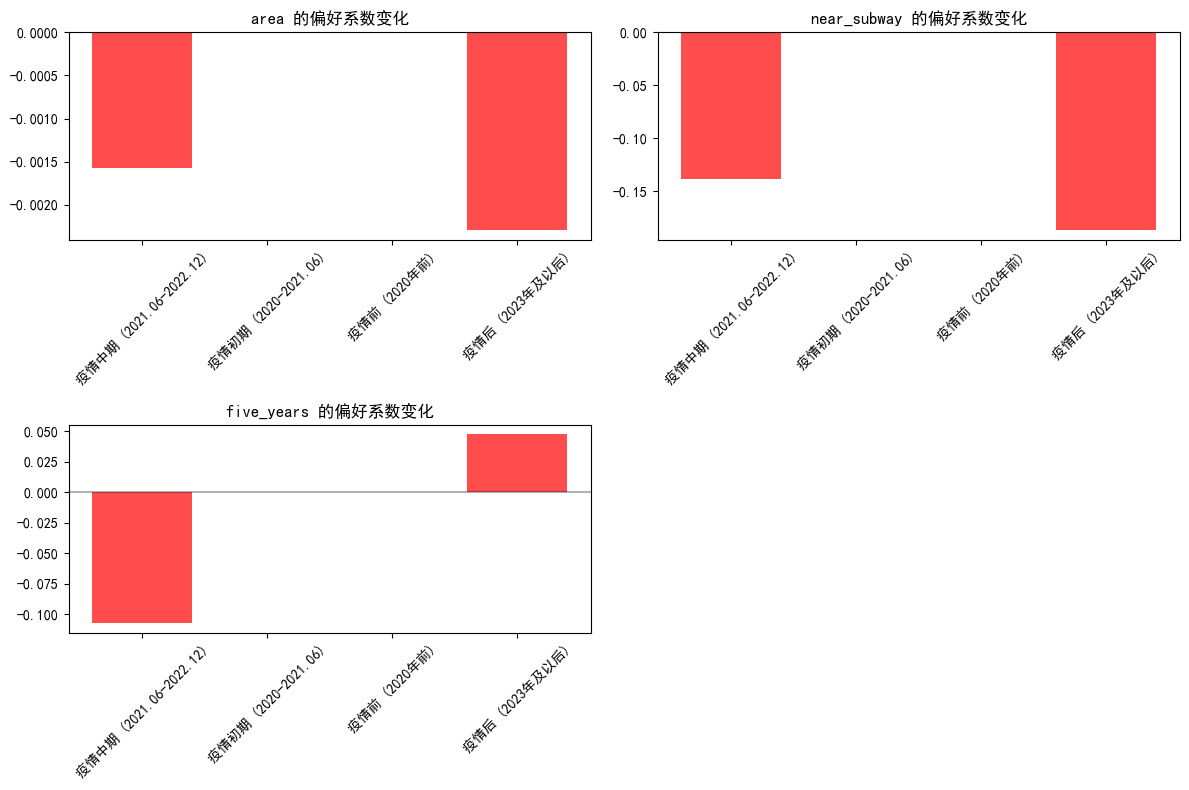

In [71]:
def analyze_preference_changes(demand_results):
    """分析消费者偏好变化"""
    preference_changes = []
    
    features = ['area', 'near_subway', 'five_years']
    
    for feature in features:
        feature_coefs = []
        periods = []
        
        for period, model in demand_results.items():
            if feature in model.params:
                coef = model.params[feature]
                p_value = model.pvalues[feature]
                feature_coefs.append(coef)
                periods.append(period)
                
                preference_changes.append({
                    'feature': feature,
                    'period': period,
                    'coefficient': coef,
                    'p_value': p_value,
                    'significant': p_value < 0.05
                })
    
    preference_df = pd.DataFrame(preference_changes)
    
    # 可视化偏好变化
    plt.figure(figsize=(12, 8))
    for i, feature in enumerate(features, 1):
        plt.subplot(2, 2, i)
        feature_data = preference_df[preference_df['feature'] == feature]
        
        if len(feature_data) > 0:
            # 按时间顺序排序
            feature_data = feature_data.sort_values('period')
            
            colors = ['red' if sig else 'blue' for sig in feature_data['significant']]
            plt.bar(feature_data['period'], feature_data['coefficient'], color=colors, alpha=0.7)
            plt.title(f'{feature} 的偏好系数变化')
            plt.xticks(rotation=45)
            plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return preference_df

preference_df = analyze_preference_changes(demand_results)

## 边际成本与markup

In [75]:
def analyze_markups(elasticity_df, shares_df):
    """分析加成率(markup)变化"""
    markup_results = []
    
    # 检查数据是否存在
    if len(elasticity_df) == 0:
        print("弹性数据为空，无法计算加成率")
        return pd.DataFrame()
    
    for period in elasticity_df['period'].unique():
        period_elasticity = elasticity_df[elasticity_df['period'] == period]
        
        # 检查该时期是否有数据
        if len(period_elasticity) == 0:
            continue
            
        # 获取该时期的市场份额数据
        period_shares = shares_df[shares_df['time_period'] == period]
        
        for idx, row in period_elasticity.iterrows():
            product_id = row['product_id']
            
            # 查找对应的市场份额数据
            product_share_data = period_shares[period_shares['product_id'] == product_id]
            
            if len(product_share_data) > 0:
                elasticity = row['own_elasticity']
                price = row['unit_price']
                market_share = product_share_data['share'].iloc[0]
                
                # 简化版Lerner指数: markup = -1/elasticity
                # 确保弹性为负且不为零
                if elasticity < -0.001:  # 避免除零和正弹性
                    markup = -1 / elasticity
                    marginal_cost = price * (1 - 1/markup)  # 修正边际成本计算
                    
                    markup_results.append({
                        'period': period,
                        'product_id': product_id,
                        'price': price,
                        'elasticity': elasticity,
                        'markup': markup,
                        'marginal_cost': marginal_cost,
                        'market_share': market_share
                    })
                else:
                    print(f"跳过产品 {product_id}: 弹性值 {elasticity:.4f} 无效")
    
    # 检查是否有结果
    if len(markup_results) == 0:
        print("没有有效的加成率计算结果")
        return pd.DataFrame()
    
    markup_df = pd.DataFrame(markup_results)
    
    # 分析加成率变化
    print("加成率分析:")
    if 'period' in markup_df.columns and len(markup_df) > 0:
        markup_summary = markup_df.groupby('period').agg({
            'markup': ['mean', 'std'],
            'price': 'mean',
            'marginal_cost': 'mean',
            'product_id': 'count'
        }).round(4)
        print(markup_summary)
    else:
        print("没有足够的数据进行分组分析")
        markup_summary = pd.DataFrame()
    
    return markup_df

# 运行前先检查数据
print("弹性数据形状:", elasticity_df.shape if 'elasticity_df' in locals() else "未定义")
print("市场份额数据形状:", shares_df.shape if 'shares_df' in locals() else "未定义")

if 'elasticity_df' in locals() and len(elasticity_df) > 0:
    markup_df = analyze_markups(elasticity_df, shares_df)
else:
    print("弹性数据不存在或为空，跳过加成率分析")
    markup_df = pd.DataFrame()

弹性数据形状: (35012, 6)
市场份额数据形状: (35012, 12)
跳过产品 11045.0: 弹性值 0.2460 无效
跳过产品 11086.0: 弹性值 0.2465 无效
跳过产品 11083.0: 弹性值 0.2065 无效
跳过产品 11078.0: 弹性值 0.4201 无效
跳过产品 11040.0: 弹性值 0.3315 无效
跳过产品 11076.0: 弹性值 0.3173 无效
跳过产品 11031.0: 弹性值 0.2964 无效
跳过产品 11080.0: 弹性值 0.2836 无效
跳过产品 11041.0: 弹性值 0.2170 无效
跳过产品 11071.0: 弹性值 0.2368 无效
跳过产品 11070.0: 弹性值 0.2464 无效
跳过产品 11058.0: 弹性值 0.2805 无效
跳过产品 11084.0: 弹性值 0.2378 无效
跳过产品 11029.0: 弹性值 0.2301 无效
跳过产品 11082.0: 弹性值 0.2596 无效
跳过产品 11030.0: 弹性值 0.2316 无效
跳过产品 11028.0: 弹性值 0.2270 无效
跳过产品 11037.0: 弹性值 0.2206 无效
跳过产品 11064.0: 弹性值 0.2026 无效
跳过产品 11065.0: 弹性值 0.2591 无效
跳过产品 11046.0: 弹性值 0.2045 无效
跳过产品 11069.0: 弹性值 0.1970 无效
跳过产品 11051.0: 弹性值 0.2810 无效
跳过产品 11075.0: 弹性值 0.2056 无效
跳过产品 11039.0: 弹性值 0.2044 无效
跳过产品 11088.0: 弹性值 0.4122 无效
跳过产品 25679.0: 弹性值 0.2428 无效
跳过产品 25760.0: 弹性值 0.1564 无效
跳过产品 25721.0: 弹性值 0.1880 无效
跳过产品 25717.0: 弹性值 0.2456 无效
跳过产品 25744.0: 弹性值 0.2270 无效
跳过产品 25654.0: 弹性值 0.2555 无效
跳过产品 25688.0: 弹性值 0.2974 无效
跳过产品 25675.0: 弹性值 0.2280 无效
跳过产品 25

## 反事实分析

In [73]:
def counterfactual_analysis(demand_results, shares_df):
    """反事实分析：如果偏好回到疫情前"""
    counterfactual_results = []
    
    # 获取疫情前的系数
    pre_covid_coefs = {}
    if '疫情前 (2020年前)' in demand_results:
        pre_model = demand_results['疫情前 (2020年前)']
        for feature in ['area', 'near_subway', 'five_years']:
            if feature in pre_model.params:
                pre_covid_coefs[feature] = pre_model.params[feature]
    
    # 对每个后期进行分析
    later_periods = [p for p in demand_results.keys() if p != '疫情前 (2020年前)']
    
    for period in later_periods:
        period_data = shares_df[shares_df['time_period'] == period].copy()
        current_model = demand_results[period]
        
        if len(pre_covid_coefs) > 0:
            # 计算反事实市场份额
            X = period_data[['unit_price', 'area', 'near_subway', 'five_years']]
            X = sm.add_constant(X)
            
            # 当前预测
            current_utility = current_model.predict(X)
            current_share = np.exp(current_utility) / (1 + np.exp(current_utility))
            
            # 反事实预测（使用疫情前系数）
            counterfactual_utility = (
                current_model.params['const'] +
                current_model.params['unit_price'] * X['unit_price'] +
                pre_covid_coefs.get('area', 0) * X['area'] +
                pre_covid_coefs.get('near_subway', 0) * X['near_subway'] +
                pre_covid_coefs.get('five_years', 0) * X['five_years']
            )
            counterfactual_share = np.exp(counterfactual_utility) / (1 + np.exp(counterfactual_utility))
            
            # 计算变化
            share_change = (counterfactual_share.mean() - current_share.mean()) / current_share.mean() * 100
            
            counterfactual_results.append({
                'period': period,
                'current_mean_share': current_share.mean(),
                'counterfactual_mean_share': counterfactual_share.mean(),
                'share_change_pct': share_change,
                'sample_size': len(period_data)
            })
    
    counterfactual_df = pd.DataFrame(counterfactual_results)
    print("反事实分析结果:")
    print(counterfactual_df)
    
    return counterfactual_df

counterfactual_df = counterfactual_analysis(demand_results, shares_df)

反事实分析结果:
                   period  current_mean_share  counterfactual_mean_share  \
0          疫情后 (2023年及以后)            0.002980                        NaN   
1  疫情中期 (2021.06-2022.12)            0.007411                        NaN   
2     疫情初期 (2020-2021.06)                 NaN                        NaN   

   share_change_pct  sample_size  
0               NaN        15760  
1               NaN         6407  
2               NaN         9220  


## 市场均衡分析

markup_df 状态: 为空
markup_df 数据不可用，只进行基础市场结构分析


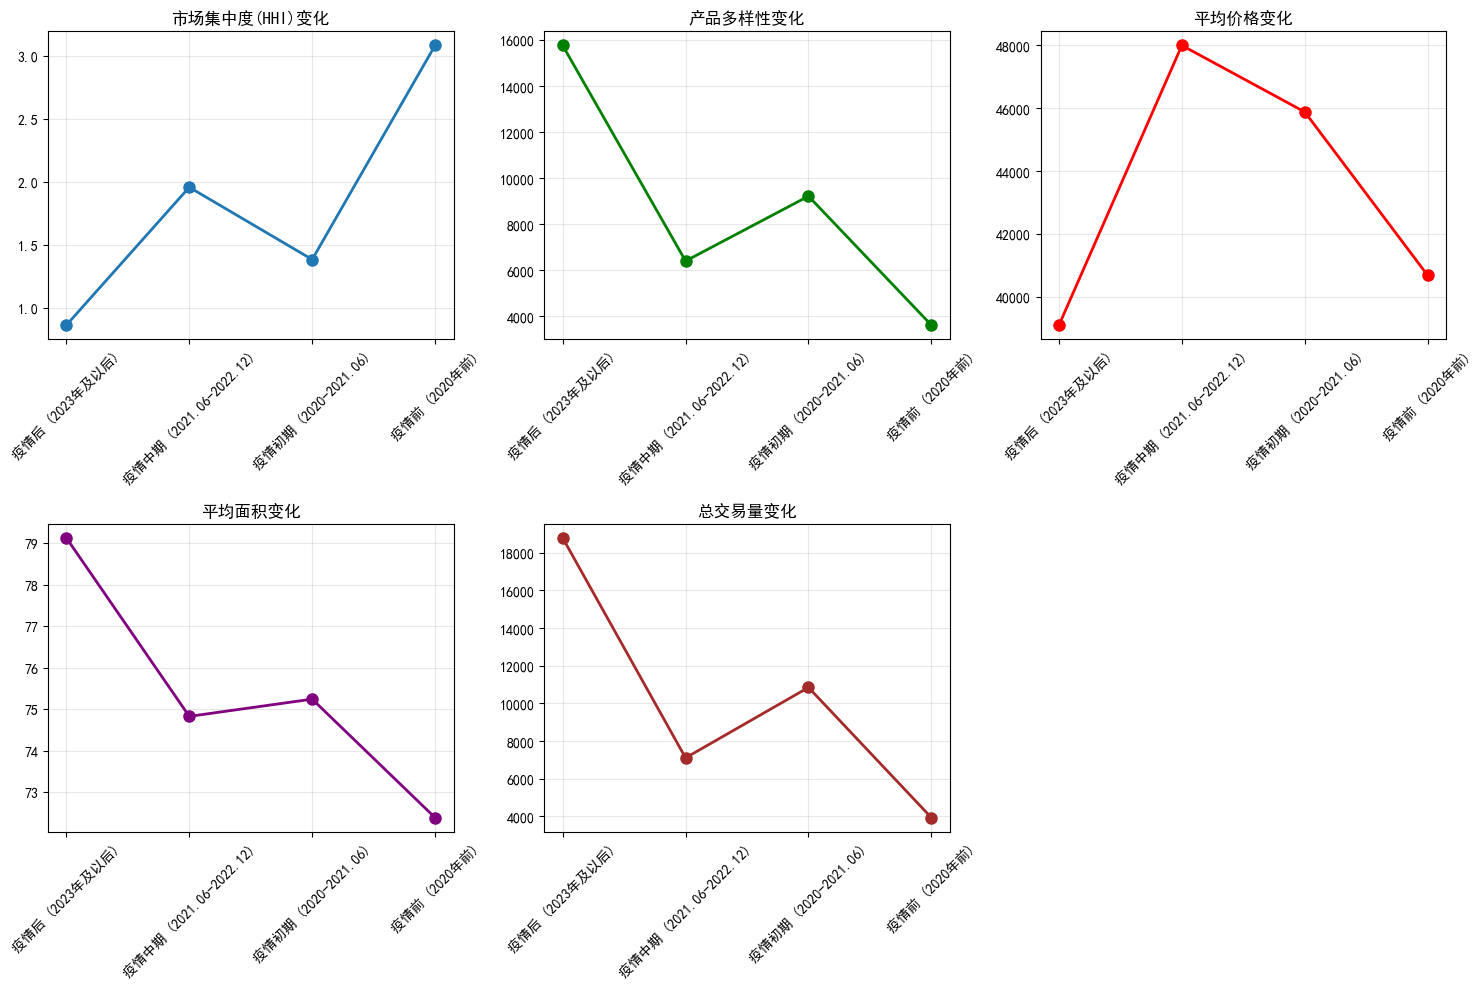

市场均衡分析结果:
                   period     HHI  avg_markup  price_cost_margin  \
0          疫情后 (2023年及以后)  0.8605         NaN                NaN   
1  疫情中期 (2021.06-2022.12)  1.9557         NaN                NaN   
2     疫情初期 (2020-2021.06)  1.3817         NaN                NaN   
3            疫情前 (2020年前)  3.0823         NaN                NaN   

   num_products  total_transactions   avg_price  avg_area  
0         15760               18786  39092.9652   79.1343  
1          6407                7112  47996.9130   74.8336  
2          9220               10849  45877.7819   75.2484  
3          3625                3939  40676.2397   72.3930  


In [77]:
def market_equilibrium_analysis(df_io, markup_df):
    """市场均衡分析"""
    equilibrium_results = []
    
    # 检查 markup_df 是否为空或没有 period 列
    if markup_df is None or len(markup_df) == 0 or 'period' not in markup_df.columns:
        print("markup_df 数据不可用，只进行基础市场结构分析")
        # 只使用 df_io 进行基础分析
        for period in df_io['time_period'].unique():
            period_data = df_io[df_io['time_period'] == period]
            
            if len(period_data) > 0:
                # 计算市场集中度
                hhi = (period_data['product_id'].value_counts(normalize=True) ** 2).sum() * 10000
                
                equilibrium_results.append({
                    'period': period,
                    'HHI': hhi,
                    'avg_markup': np.nan,
                    'price_cost_margin': np.nan,
                    'num_products': period_data['product_id'].nunique(),
                    'total_transactions': len(period_data),
                    'avg_price': period_data['unit_price'].mean(),
                    'avg_area': period_data['area'].mean()
                })
    else:
        # 使用完整数据进行分析
        for period in df_io['time_period'].unique():
            period_data = df_io[df_io['time_period'] == period]
            period_markup = markup_df[markup_df['period'] == period]
            
            if len(period_data) > 0:
                # 计算市场集中度
                hhi = (period_data['product_id'].value_counts(normalize=True) ** 2).sum() * 10000
                
                if len(period_markup) > 0:
                    # 平均加成率
                    avg_markup = period_markup['markup'].mean()
                    # 价格成本边际
                    avg_price_cost_margin = period_markup['price'].mean() - period_markup['marginal_cost'].mean()
                else:
                    avg_markup = np.nan
                    avg_price_cost_margin = np.nan
                
                equilibrium_results.append({
                    'period': period,
                    'HHI': hhi,
                    'avg_markup': avg_markup,
                    'price_cost_margin': avg_price_cost_margin,
                    'num_products': period_data['product_id'].nunique(),
                    'total_transactions': len(period_data),
                    'avg_price': period_data['unit_price'].mean(),
                    'avg_area': period_data['area'].mean()
                })
    
    equilibrium_df = pd.DataFrame(equilibrium_results)
    
    if len(equilibrium_df) == 0:
        print("没有有效的均衡分析数据")
        return pd.DataFrame()
    
    # 可视化市场结构变化
    plt.figure(figsize=(15, 10))
    
    # 确定可用的指标
    available_columns = equilibrium_df.columns
    
    plot_count = 0
    if 'HHI' in available_columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['HHI'], 'o-', linewidth=2, markersize=8)
        plt.title('市场集中度(HHI)变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    if 'avg_markup' in available_columns and not equilibrium_df['avg_markup'].isna().all():
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['avg_markup'], 'o-', color='orange', linewidth=2, markersize=8)
        plt.title('平均加成率变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    if 'num_products' in available_columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['num_products'], 'o-', color='green', linewidth=2, markersize=8)
        plt.title('产品多样性变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    if 'avg_price' in available_columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['avg_price'], 'o-', color='red', linewidth=2, markersize=8)
        plt.title('平均价格变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    if 'avg_area' in available_columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['avg_area'], 'o-', color='purple', linewidth=2, markersize=8)
        plt.title('平均面积变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    if 'total_transactions' in available_columns:
        plot_count += 1
        plt.subplot(2, 3, plot_count)
        plt.plot(equilibrium_df['period'], equilibrium_df['total_transactions'], 'o-', color='brown', linewidth=2, markersize=8)
        plt.title('总交易量变化')
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("市场均衡分析结果:")
    print(equilibrium_df.round(4))
    
    return equilibrium_df

# 运行前检查数据
print("markup_df 状态:", 
      "为空" if markup_df is None or len(markup_df) == 0 else 
      f"有 {len(markup_df)} 行数据，列: {list(markup_df.columns)}")

equilibrium_df = market_equilibrium_analysis(df_io, markup_df)